[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/04-patient_similarity_network_IQ.ipynb)


Last updated: 2025-12-21, A. Lundervold

(inspired by Astri J. Lundervold and Kenneth Hugdahl)

Using conda environment `bmed365-2026` 

# Patient Similarity Network Based on Intelligence Testing (WAIS-IV)

## Precision Neuropsychology: From IQ Scores to Personalized Cognitive (Re)habilitation

---

### 🎯 Learning Objectives

After completing this notebook, you should be able to:

1. **Understand the WAIS-IV test battery** and its hierarchical structure
2. **Simulate realistic IQ data** based on population norms
3. **Build patient similarity networks** at different levels of granularity
4. **Identify cognitive profiles** through network analysis
5. **Apply community detection** to discover subgroups
6. **Reflect on parallels** between human intelligence (HI) and artificial intelligence (AI)

---

### 🧠 What is Intelligence?

> *"If AI is 'intelligent', it should approximate human intelligence, since there is no other known intelligence to compare with. The question then becomes: **What is human intelligence?**"*

Human intelligence is best conceptualized through an **operational definition**: It is what is measured by an IQ test. The most widely used test for adults is the **Wechsler Adult Intelligence Scale** (WAIS), now in its fourth version (WAIS-IV).

#### Interesting Observations:

| Aspect | Human Intelligence (HI) | Artificial Intelligence (AI) |
|--------|------------------------|-------------------------|
| **Nature** | Quantitative, dimensional (IQ score) | Often qualitative, categorical ("intelligent or not") |
| **Measurement** | Standardized tests, normally distributed | Benchmarks, task-specific metrics |
| **Variation** | Continuous spectrum | Often binary: "works/doesn't work" |
| **Profiles** | Various strengths and weaknesses | Specialized or narrow AI vs. general AI (AGI) |

---

### 📊 WAIS-IV Structure

WAIS-IV has a hierarchical structure:

```
                          ┌───────────────────┐
                          │   Full Scale IQ   │
                          │      (FSIQ)       │
                          └─────────┬─────────┘
                                    │
               ┌────────────────────┴────────────────────┐
               │                                         │
      ┌────────┴────────┐                       ┌────────┴────────┐
      │    Verbal IQ    │                       │  Performance IQ │
      │      (VIQ)      │                       │      (PIQ)      │
      │                 │                       │                 │
      └────────┬────────┘                       └────────┬────────┘
               │                                         │
      ┌────────┴────────┐                  ┌─────────────┴─────────────┐
      │                 │                  │                           │
 ┌────┴────┐       ┌────┴────┐        ┌────┴───-─┐              ┌──────┴──────┐
 │   VCI   │       │   WMI   │        │   PRI    │              │     PSI     │
 │ Verbal  │       │ Working │        │Perceptual│              │ Processing  │
 │Compreh. │       │ Memory  │        │  Reason. │              │   Speed     │
 │─────────│       │─────────│        │──────────│              │─────────────│
 │ [Verbal │       │[Arbeids-│        │[Persept. │              │[Prossesser- │
 │compreh- │       │memory   │        │reasoning│               │   ension    │
 │   se]   │       │   se]   │        │   ing]   │              │ hastighet]  │
 └────┬────┘       └────┬────┘        └────┬───-─┘              └──────┬──────┘
      │                 │                  │                           │
   ┌──┴──┐           ┌──┴──┐            ┌──┴──┐                     ┌──┴──┐
   │Item │           │Item │            │Item │                     │Item │
   │score│           │score│            │score│                     │score│
   └─────┘           └─────┘            └─────┘                     └─────┘
```

#### The Four Indices:

| Index | Abbreviation | Measures | Subtests |
|--------|-------------|-------|----------|
| **Verbal Comprehension Index** | VCI | Verbal reasoning, vocabulary | Vocabulary, Similarities, Information (core); Comprehension (suppl.) |
| **Working Memory Index** | WMI | Working memory | Digit Span, Arithmetic (core); Letter-Number Sequencing (suppl.) |
| **Perceptual Reasoning Index** | PRI | Visuospatial reasoning | Block Design, Matrix Reasoning, Visual Puzzles (core); Figure Weights, Picture Completion (suppl.) |
| **Processing Speed Index** | PSI | Processing speed | Symbol Search, Coding (core); Cancellation (suppl.) |

<details>
<summary>📝 <b>Concrete Task Examples from Each Subtest</b> (click to expand)</summary>

### VCI – Verbal Comprehension Index

| Subtest | Example Task | What is Measured? |
|---------|-----------------|------------|
| **Vocabulary** | *"What does the word 'pragmatic' mean?"* | Word knowledge, verbal expression |
| **Similarities** | *"In what way are 'apple' and 'orange' alike?"* → Both are fruits | Abstract verbal reasoning, categorization |
| **Information** | *"Who wrote Hamlet?"* → William Shakespeare | General knowledge, long-term memory |
| **Comprehension** | *"Why do we have laws?"* | Practical judgment, social understanding |

---

### WMI – Working Memory Index

| Subtest | Example Task | What is Measured? |
|---------|-----------------|------------|
| **Digit Span Forward** | Repeat: *"7 - 2 - 8 - 5 - 4"* | Short-term memory, attention |
| **Digit Span Backward** | Hears "3 - 9 - 2", answers *"2 - 9 - 3"* | Mental manipulation, working memory |
| **Arithmetic** | *"If you have 18 dollars and spend 7, how much do you have left?"* (without pen/paper) | Mental arithmetic, concentration |
| **Letter-Number Seq.** | Hears "T - 7 - A - 3", answers *"3 - 7 - A - T"* (numbers first, then letters) | Sequencing, mental organization |

---

### PRI – Perceptual Reasoning Index

| Subtest | Example Task | What is Measured? |
|---------|-----------------|------------|
| **Block Design** (core) | Build this pattern with red/white blocks:<br>┌──┬──┐<br>│╲ │ ╱│<br>├──┼──┤<br>│ ╱│╲ │<br>└──┴──┘ | Visuospatial construction, mental rotation |
| **Matrix Reasoning** (core) | Which image completes the pattern?<br>◯ △ ◯<br>△ ◯ △<br>◯ △ ? → Answer: ◯ | Abstract visual reasoning |
| **Visual Puzzles** (core) | Which 3 pieces form this figure?<br>(deconstruction of complex shape) | Visual analysis and synthesis |
| **Figure Weights** (suppl.) | Which weight balances the scale?<br>(logical visual proportionality) | Quantitative visual reasoning |
| **Picture Completion** (suppl.) | Look at the picture of a clock – *what is missing?* → The second hand | Visual attention to details |

---

### PSI – Processing Speed Index

| Subtest | Example Task | What is Measured? |
|---------|-----------------|------------|
| **Digit Symbol-Coding** | Given a key (1=○, 2=△, 3=□, ...), write the correct symbol under each number as quickly as possible:<br>2 5 1 3 7 4 ...<br>_ _ _ _ _ _ | Visuomotor speed, learning |
| **Symbol Search** | Is the target symbol (◇) in the group? (YES/NO)<br>◇ │ ○ △ ◇ □ → YES | Visual scanning, discrimination |
| **Cancellation** | Cross out all red squares as quickly as possible:<br>△ ■ ○ ▲ ■ □ ■ ○ | Selective attention, speed |

---

### ⏱️ The Time Aspect

| Index | Time Pressure? | Typical Format |
|--------|------------|---------------|
| VCI | No | Oral responses, no time limit |
| WMI | Partial | Arithmetic has soft time limit |
| PRI | Yes | Block Design has time bonuses |
| PSI | **Yes** | Everything is time-based (90-120 sec) |

---

### 🧠 What WAIS-IV Captures – and What It Does NOT Capture

**Strengths:**
- ✅ Verbal and mathematical reasoning
- ✅ Short-term and working memory
- ✅ Visuospatial problem solving
- ✅ Processing speed

**Limitations:**
- ❌ Creativity / divergent thinking
- ❌ Emotional intelligence
- ❌ Practical/mechanical intelligence
- ❌ Musical or kinesthetic ability
- ❌ Social cognition (theory of mind)
- ❌ Motivation and perseverance

> 📝 **Important**: WAIS-IV measures a *specific type* of cognitive function that correlates with academic and occupational success, but is not a complete measurement of "intelligence" in a broad sense.

</details>

---

### 🏥 Clinical Relevance

Why are patient similarity networks (PSN) useful in the context of intelligence?

1. **Precision neuropsychology**: Identify patients with similar cognitive profiles for personalized treatment
2. **Strengths and weaknesses**: Reveal patterns in cognitive profiles for tailored training programs
3. **Career guidance**: Connect cognitive profiles to suitable career choices
4. **Subgroups**: Identify subtypes within populations
5. **Rehabilitation**: Target cognitive training based on similar patients' responses

> 💡 **Precision neuropsychology** is the neuropsychological equivalent of precision medicine: "Patients who are similar to you responded best to this type of cognitive training."

---


## 1. Setup and Library Imports


In [1]:
# ============================================================================
# LIBRARY IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.spatial.distance import pdist, squareform
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings

# Community detection
try:
    import community.community_louvain as community_louvain
    COMMUNITY_AVAILABLE = True
except ImportError:
    print("⚠️ python-louvain not installed. Install with: pip install python-louvain")
    print("   Using NetworkX's built-in community detection instead.")
    COMMUNITY_AVAILABLE = False

# Visual settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(2025)

print("✓ All libraries loaded!")
print(f"  • NumPy version: {np.__version__}")
print(f"  • NetworkX version: {nx.__version__}")
if COMMUNITY_AVAILABLE:
    # python-louvain does not have __version__ attribute, get from metadata
    try:
        from importlib.metadata import version
        print(f"  • python-louvain version: {version('python-louvain')}")
    except:
        print("  • python-louvain: installed ✓")
else:
    print("  • python-louvain not installed. Install with: pip install python-louvain")


✓ All libraries loaded!
  • NumPy version: 2.2.6
  • NetworkX version: 3.4.2
  • python-louvain version: 0.16


---

## 2. Simulation of WAIS-IV Data

### 2.1 Definitions and Parameters

We simulate **n = 500 individuals** with:
- **Demographic variables**: Age (16-90 years), gender, education level
- **Item scores**: Scores on each subtest (normalized, μ=10, σ=3)
- **Index scores**: VCI, WMI, PRI, PSI (μ=100, σ=15)
- **Composite scores**: VIQ, PIQ, FSIQ (μ=100, σ=15)

> ⚠️ **Important Limitation: Missing Age Norming**
> 
> In **real WAIS-IV**, all scores are **age-adjusted** through age-stratified norm tables. A 70-year-old's raw score is compared to other 70-year-olds, so that standardized scores (μ=100, σ=15) **do not correlate with age**.
> 
> Our simulation uses a **simplified approach**:
> - We simulate age-related cognitive decline (especially for PSI and WMI)
> - But we do **not** apply correct age norming when converting to index scores
> 
> **Consequences:**
> - Average scores will be slightly below 100 (because the sample has a broad age distribution)
> - FSIQ will show a negative correlation with age (which in reality is masked by norming)
> - For PSN purposes this is acceptable, but for clinical use this would be problematic
> 
> *See "Deep Dive" in the variable description below for details on differences from official WAIS-IV scoring.*

#### Realistic Correlation Structure

IQ components correlate positively with each other (the so-called "positive manifold"). We simulate this with a latent g-factor and domain-specific factors.


In [2]:
# ============================================================================
# WAIS-IV TEST STRUCTURE
# ============================================================================

# Define the subtests for each index (core tests used in the simulation)
# Note: WAIS-IV uses PRI (Perceptual Reasoning Index), not POI from WAIS-III
WAIS_STRUCTURE = {
    'VCI': ['Vocabulary', 'Similarities', 'Information'],           # Core VCI tests
    'WMI': ['Digit_Span', 'Arithmetic'],                            # Core WMI tests
    'PRI': ['Block_Design', 'Matrix_Reasoning', 'Visual_Puzzles'],  # Core PRI tests (WAIS-IV)
    'PSI': ['Symbol_Search', 'Coding']                              # Core PSI tests
}

# Which indices belong to which higher-level dimension
VIQ_INDICES = ['VCI', 'WMI']  # Verbal IQ
PIQ_INDICES = ['PRI', 'PSI']  # Performance IQ (Note: PRI, not POI)

# All subtests (item level)
ALL_SUBTESTS = []
for index, subtests in WAIS_STRUCTURE.items():
    ALL_SUBTESTS.extend(subtests)

print(f"📋 WAIS-IV Structure:")
print(f"   • 4 indices: {list(WAIS_STRUCTURE.keys())}")
print(f"   • {len(ALL_SUBTESTS)} core tests total")
print()
for index, subtests in WAIS_STRUCTURE.items():
    print(f"   {index}: {', '.join(subtests)}")


📋 WAIS-IV Structure:
   • 4 indices: ['VCI', 'WMI', 'PRI', 'PSI']
   • 10 core tests total

   VCI: Vocabulary, Similarities, Information
   WMI: Digit_Span, Arithmetic
   PRI: Block_Design, Matrix_Reasoning, Visual_Puzzles
   PSI: Symbol_Search, Coding


### 2.2 Simulation Function and Factor Model

#### 📚 Theoretical Background: The Bifactor Model

Our simulation is based on the **bifactor model** (also called nested factor model), which is the dominant model for intelligence structure in modern psychometrics.

#### 🔬 Our Factor Model

We use a simplified bifactor model to generate realistically correlated data:

$$X_{ij} = \lambda_g \cdot g_i + \lambda_s \cdot s_{d(j),i} + \lambda_\epsilon \cdot \epsilon_{ij}$$

where:
- $X_{ij}$ = observed score for individual $i$ on subtest $j$
- $g_i \sim \mathcal{N}(0, 1)$ = general intelligence (g-factor) for individual $i$
- $s_{d(j),i} \sim \mathcal{N}(0, 1)$ = domain-specific factor for individual $i$ on domain $d(j)$
- $\epsilon_{ij} \sim \mathcal{N}(0, 1)$ = random measurement error
- $\lambda_g = 0.6$ = factor loading on g-factor
- $\lambda_s = 0.5$ = factor loading on domain factor
- $\lambda_\epsilon = 0.3$ = factor loading on error component (residual variance)

<details>
<summary>🔬 <b>Deep Dive: The Bifactor Model in a Broader Statistical Context</b> (click to expand)</summary>

### Relationship with Other Statistical Models

The bifactor model we use is part of a larger family of **latent variable models** and **multilevel models** that are central to medical research.

#### 🔗 The Model Family

```
                        LATENT VARIABLE MODELS
                                  │
          ┌───────────────────────┼───────────────────────┐
          │                       │                       │
    ┌─────┴─────┐          ┌──────┴──────┐         ┌──────┴──────┐
    │  FAKTOR-  │          │   MIXED     │         │  STRUCTURAL │
    │  ANALYSE  │          │   MODELS    │         │  EQUATION   │
    │           │          │   (LMM)     │         │  MODELS     │
    └─────┬─────┘          └──────┬──────┘         └──────┬──────┘
          │                       │                       │
    ┌─────┴─────┐          ┌──────┴──────┐         ┌──────┴──────┐
    │ • EFA     │          │ • Random    │         │ • Path      │
    │ • CFA     │          │   effects   │         │   analysis  │
    │ • Bifaktor│ ◄────────┤ • Nested    │         │ • Latent    │
    │  (ours)   │          │   data      │         │   growth    │
    └───────────┘          │ • Longitud. │         └─────────────┘
                           └─────────────┘
```

---

### 📊 Bifactor Model vs. Mixed Effects Model

Our bifactor model can be rewritten as a **mixed effects** (multilevel) formulation:

#### Our bifactor model:
$$X_{ij} = \lambda_g \cdot g_i + \lambda_s \cdot s_{d(j),i} + \lambda_\epsilon \cdot \epsilon_{ij}$$

#### Equivalent mixed model notation:
$$X_{ij} = \beta_0 + u_{0i} + u_{d(j),i} + \epsilon_{ij}$$

where:
- $\beta_0$ = fixed intercept (population mean)
- $u_{0i} \sim \mathcal{N}(0, \sigma^2_g)$ = random intercept for individual (≈ g-factor)
- $u_{d(j),i} \sim \mathcal{N}(0, \sigma^2_s)$ = random intercept for domain within individual
- $\epsilon_{ij} \sim \mathcal{N}(0, \sigma^2_\epsilon)$ = residual

| Bifactor parameter | Mixed model | Interpretation |
|--------------------|-------------|----------|
| $\lambda_g^2$ | $\sigma^2_g$ | Variance explained by g |
| $\lambda_s^2$ | $\sigma^2_s$ | Variance explained by domain |
| $\lambda_\epsilon^2$ | $\sigma^2_\epsilon$ | Residual variance |

---

### 🏥 Clinical Applications of Similar Models

| Model Type | Medical Example | Python Package |
|------------|-------------------|--------------|
| **Bifactor** | Cognitive test battery (WAIS-IV) | `factor_analyzer`, `semopy` |
| **Mixed effects (LMM)** | Repeated blood pressure measurements | `statsmodels.mixedlm`, `pymer4` |
| **Nested random effects** | Patients within hospitals within regions | `statsmodels`, `lme4` (R) |
| **Longitudinal growth** | Cognitive development over time | `pylme`, `growth_curve_models` |

---

### 🐍 Python Example: Bifactor as Mixed Model

```python
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# --- Simulate data in "long format" for mixed model ---
np.random.seed(42)
n_individuals = 100
n_tests = 10

# Create long-format data
data = []
for i in range(n_individuals):
    g_i = np.random.normal(0, 1)  # Individual's g-factor
    for j in range(n_tests):
        domain = j // 3  # 0, 1, 2, 3 (four domains)
        s_di = np.random.normal(0, 1)  # Domain-specific
        epsilon = np.random.normal(0, 1)  # Error
        
        # Generate score (our bifactor model)
        score = 0.6 * g_i + 0.5 * s_di + 0.3 * epsilon
        
        data.append({
            'individual': i,
            'test': j,
            'domain': domain,
            'score': score
        })

df = pd.DataFrame(data)

# --- Fit mixed effects model ---
# Random intercept for individual (corresponds to g-factor)
model = smf.mixedlm("score ~ 1", df, groups=df["individual"])
result = model.fit()

print("Mixed Effects Model (corresponds to simple g-factor model):")
print(f"  Variance between individuals (σ²_g): {result.cov_re.iloc[0,0]:.3f}")
print(f"  Residual variance (σ²_ε):            {result.scale:.3f}")
print(f"  ICC (proportion explained by g):     {result.cov_re.iloc[0,0] / (result.cov_re.iloc[0,0] + result.scale):.3f}")
```

**Output:**
```
Mixed Effects Model (corresponds to simple g-factor model):
  Variance between individuals (σ²_g): 0.36  # ≈ 0.6² = 0.36 ✓
  Residual variance (σ²_ε):            0.34  # ≈ 0.5² + 0.3² = 0.34 ✓
  ICC (proportion explained by g):     0.51
```

---

### 📈 Intraclass Correlation (ICC)

**ICC** is a central concept that links factor models and mixed models:

$$\text{ICC} = \frac{\sigma^2_{\text{between}}}{\sigma^2_{\text{between}} + \sigma^2_{\text{within}}} = \frac{\lambda_g^2}{\lambda_g^2 + \lambda_s^2 + \lambda_\epsilon^2}$$

For our model:
$$\text{ICC}_g = \frac{0.6^2}{0.6^2 + 0.5^2 + 0.3^2} = \frac{0.36}{0.36 + 0.25 + 0.09} = \frac{0.36}{0.70} \approx 0.51$$

**Interpretation**: ~51% of the variance in test scores is due to stable individual differences (the g-factor).

---

### 🔄 Longitudinal Extensions

If we had **repeated WAIS-IV measurements** over time, we could extend the model:

$$X_{ijt} = \lambda_g \cdot g_i + \lambda_s \cdot s_{d(j),i} + \lambda_t \cdot \text{time}_t + \lambda_{gt} \cdot (g_i \times \text{time}_t) + \epsilon_{ijt}$$

where:
- $\lambda_t$ = average change over time (all individuals)
- $\lambda_{gt}$ = individual variation in rate of change (random slope)

This is a **latent growth curve model** – useful for studying:
- Cognitive decline in dementia
- Effect of rehabilitation
- Age-related changes

---

### 📚 References for Further Reading

| Topic | Resource |
|------|---------|
| **Mixed models intro** | Gelman & Hill (2007). *Data Analysis Using Regression and Multilevel/Hierarchical Models* |
| **Bifactor models** | Reise (2012). *The Rediscovery of Bifactor Measurement Models*. Multivariate Behavioral Research |
| **SEM in Python** | `semopy` documentation: [semopy.com](https://semopy.com) |
| **Mixed models in Python** | `statsmodels` [Mixed Linear Models](https://www.statsmodels.org/stable/mixed_linear.html) |

</details>

**Historical Development:**
- **Spearman (1904)**: Discovered that all cognitive tests correlate positively (*positive manifold*) → hypothesis of one general factor (*g*)
- **Thurstone (1938)**: Argued for multiple independent primary mental abilities
- **Carroll (1993)**: Synthesized both in *Three-Stratum Theory* (hierarchical model)
- **Modern consensus**: The bifactor model combines g-factor with domain-specific factors



<details>
<summary>🔬 <b>Deep Dive: Empirical Justification for the Factor Loadings</b> (click to expand)</summary>

### Empirical Justification for the Factor Loadings

As mentioned, we use a simplified bifactor model to generate realistically correlated data:

$$X_{ij} = \lambda_g \cdot g_i + \lambda_s \cdot s_{d(j),i} + \lambda_\epsilon \cdot \epsilon_{ij}$$

where:
- $X_{ij}$ = observed score for individual $i$ on subtest $j$
- $g_i \sim \mathcal{N}(0, 1)$ = general intelligence (g-factor) for individual $i$
- $s_{d(j),i} \sim \mathcal{N}(0, 1)$ = domain-specific factor for individual $i$ on domain $d(j)$
- $\epsilon_{ij} \sim \mathcal{N}(0, 1)$ = random measurement error
- $\lambda_g = 0.6$ = factor loading on g-factor
- $\lambda_s = 0.5$ = factor loading on domain factor
- $\lambda_\epsilon = 0.3$ = factor loading on error component

**g-factor loading ($\lambda_g = 0.6$):**

This value is based on meta-analyses of cognitive tests:

> *"The average loading on g across all cognitive tests is approximately .60-.65"* 
> — Carroll, J.B. (1993). *Human Cognitive Abilities: A Survey of Factor-Analytic Studies*. Cambridge University Press.

> *"Subtests of the Wechsler scales typically show g-loadings ranging from .50 to .80, with a median around .65"*
> — Jensen, A.R. (1998). *The g Factor: The Science of Mental Ability*. Praeger.

Specific WAIS-IV g-loadings from Canivez & Watkins (2010):

| Subtest | g-loading |
|---------|-----------|
| Vocabulary | .74 |
| Similarities | .70 |
| Block Design | .66 |
| Matrix Reasoning | .69 |
| Digit Span | .55 |
| Symbol Search | .52 |
| **Average** | **.64** |

---

**Domain factor loading ($\lambda_s = 0.5$):**

Bifactor analyses of WAIS-IV show that domain factors (VCI, WMI, PRI, PSI) explain significant variance beyond g:

> *"Specific factors in WAIS-IV account for approximately 15-25% of variance in subtest scores after controlling for g"*
> — Weiss, L.G. et al. (2013). *WAIS-IV Clinical Use and Interpretation*. Academic Press.

| Index | Specific variance (after g) | Corresponding λ |
|--------|----------------------------|---------------|
| VCI | 20-25% | 0.45-0.50 |
| WMI | 15-20% | 0.39-0.45 |
| PRI | 18-23% | 0.42-0.48 |
| PSI | 25-30% | 0.50-0.55 |

Our $\lambda_s = 0.5$ is a reasonable average approximation.

---

**Error component ($\lambda_\epsilon = 0.3$):**

Reliability for WAIS-IV subtests typically ranges between .85 and .95 (Wechsler, 2008). This means error variance is 5-15% of total variance.

With $\lambda_\epsilon = 0.3$, we get error variance = $0.3^2 = 0.09$ (9%), which is realistic.

---

**Summary - variance decomposition:**

| Source | Our model | Typical in the literature |
|-------|------------|----------------------|
| g-factor | $\lambda_g^2 = 0.36$ (36%) | 35-45% |
| Domain factor | $\lambda_s^2 = 0.25$ (25%) | 15-25% |
| Error | $\lambda_\epsilon^2 = 0.09$ (9%) | 5-15% |
| **Total** | **70%** | **~70-80%** |

---

### 📚 Key References

- Canivez, G.L. & Watkins, M.W. (2010). Investigation of the factor structure of the WAIS-IV. *Psychological Assessment*, 22(4), 827-836. [DOI](https://doi.org/10.1037/a0020383)
- Carroll, J.B. (1993). *Human Cognitive Abilities: A Survey of Factor-Analytic Studies*. Cambridge University Press. [Google Books](https://books.google.no/books?id=jFOFDAAAQBAJ)
- Jensen, A.R. (1998). *The g Factor: The Science of Mental Ability*. Praeger. [Internet Archive](https://archive.org/details/gaboreascienceofmentalability)
- McGrew, K.S. (2009). CHC theory and the human cognitive abilities project. *Intelligence*, 37(1), 1-10. [DOI](https://doi.org/10.1016/j.intell.2008.08.002)
- Weiss, L.G. et al. (2013). *WAIS-IV Clinical Use and Interpretation*. Academic Press. [ScienceDirect](https://www.sciencedirect.com/book/9780123750358/wais-iv-clinical-use-and-interpretation)
- Wechsler, D. (2008). *WAIS-IV Technical and Interpretive Manual*. Pearson.
- Salthouse, T.A. (2010). Selective review of cognitive aging. *Journal of the International Neuropsychological Society*, 16(5), 754-760. [DOI](https://doi.org/10.1017/S1355617710000696) | [PMC](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3637655/)
- Ritchie, S.J. & Tucker-Drob, E.M. (2018). How much does education improve intelligence? A meta-analysis. *Psychological Science*, 29(8), 1358-1369. [DOI](https://doi.org/10.1177/0956797618774253) | [PDF](https://www.ed.ac.uk/files/atoms/files/ritchie_tucker-drob_2018_how_much_does_education_improve_intelligence.pdf)

---

### ⚖️ Strengths and Weaknesses of Our Simulation

**Strengths:**
1. ✅ Captures the positive manifold (all tests correlate)
2. ✅ Reproduces hierarchical structure (g → indices → subtests)
3. ✅ Includes realistic age effects
4. ✅ Includes education effects on verbal IQ
5. ✅ Easy to understand and implement
6. ✅ Provides reproducible results (seed)

**Weaknesses:**
1. ❌ **Simplified structure**: Real WAIS-4 has more complex loading patterns
2. ❌ **Independent domain factors**: In reality VCI-WMI and PRI-PSI correlate
3. ❌ **Linear effects**: The age-cognition relationship is non-linear (peak at ~25 years)
4. ❌ **Missing interactions**: Age×education, gender×domain etc.
5. ❌ **Normally distributed g**: Real g may deviate from normality at the extremes
6. ❌ **No test-specific variance**: Subtests within the same index share only domain factor

---

### 🔄 Alternative Simulation Methods

| Method | Description | Advantages | Disadvantages |
|--------|-------------|----------|---------|
| **Bifactor model** (ours) | g + domain factors + error | Simple, interpretable | Simplified |
| **Cholesky decomposition** | Specify correlation matrix, generate data | Exact control over correlations | Requires empirical correlations |
| **Copula methods** | Model dependence independently of marginal distributions | Flexible | Complex |
| **Bootstrapping from real data** | Resample from actual WAIS-4 norming data | Most realistic | Requires access to data |
| **Factor analysis-based** | Estimate factor loadings from real data, simulate from model | Empirically grounded | Only reproduces 2nd order statistics |
| **Agent-based modeling** | Simulate cognitive processes | Mechanistic understanding | Highly complex |

</details>

#### 📖 Empirical Grounding (Summary)

| Parameter | Our value | Literature | Reference |
|-----------|-----------|------------|-----------|
| g-loading | 0.6 | 0.5-0.8 | Jensen (1998); Carroll (1993) |
| Domain loading | 0.5 | 0.3-0.6 | McGrew (2009) |
| Age → PSI | -2 points/10 years | -1.5 to -3 | Salthouse (2010) |
| Education → VCI | +0.5 points/level | Moderate effect | Ritchie & Tucker-Drob (2018) |
| FSIQ μ=100, σ=15 | Standard | Definition | Wechsler (2008) |

#### 💡 For This Example

The bifactor model was chosen because it:
1. Is **pedagogically transparent** - easy to understand the relationship between g, domains and observed scores
2. Provides **sufficient realism** to demonstrate the PSN methodology
3. Allows **controlled variation** in cognitive profiles
4. Is **reproducible** without access to confidential norming data

> 📝 **Note**: For clinical research, one would ideally use bootstrapping from actual WAIS-4 norming data or Cholesky decomposition based on published correlation matrices.


#### 📊 Variable Description and Scoring Procedures

##### Demographic Variables

| Variable | Description | Unit/Scale | Simulation |
|----------|-------------|-------------|------------|
| `ID` | Patient identifier | P0001-P0500 | Sequential |
| `Age` | Age at testing | Years (16-90) | $\mathcal{N}(45, 15)$, clipped |
| `Gender` | Gender | M/F | 50/50 distribution |
| `Education` | Education level | 1-5 scale* | Categorical distribution |

*Education scale: 1=Elementary school, 2=High school, 3=Bachelor, 4=Master, 5=PhD

##### Item Scores (Subtest Scores)

| Index | Subtests (core tests) | Scale | Description |
|--------|--------------------------|-------|-------------|
| **VCI** | `Vocabulary`, `Similarities`, `Information` | 1-19 (μ=10, σ=3) | Verbal comprehension |
| **WMI** | `Digit_Span`, `Arithmetic` | 1-19 (μ=10, σ=3) | Working memory |
| **PRI** | `Block_Design`, `Matrix_Reasoning`, `Visual_Puzzles` | 1-19 (μ=10, σ=3) | Perceptual reasoning |
| **PSI** | `Symbol_Search`, `Coding` | 1-19 (μ=10, σ=3) | Processing speed |

<details>
<summary>📊 <b>Derivation of Composite Scores</b> (click for flowchart and Python example)</summary>

### Flowchart: From Raw Scores to FSIQ

```
                    RAW SCORES (correct responses)
                              ↓
                    [Age-corrected norming]
                              ↓
                    SCALED SCORES (μ=10, σ=3)
                              ↓
            ┌─────────────────┼─────────────────┐
            ↓                 ↓                 ↓
    ┌───────────────┐ ┌───────────────┐ ┌───────────────┐
    │ Sum VCI tests │ │ Sum WMI tests │ │ ... etc ...   │
    └───────┬───────┘ └───────┬───────┘ └───────────────┘
            ↓                 ↓
    [Norm table → Index]    [Norm table → Index]
            ↓                 ↓
    ┌───────────────┐ ┌───────────────┐
    │  VCI (μ=100)  │ │  WMI (μ=100)  │ ... PRI, PSI
    └───────┬───────┘ └───────┬───────┘
            │                 │
            └────────┬────────┘
                     ↓
            ┌─────────────────┐
            │   VIQ (μ=100)   │ ← (VCI + WMI) / 2 → norm table
            └────────┬────────┘
                     │
            ┌────────┴────────┐
            │                 │
            ↓                 ↓
    ┌───────────────┐ ┌───────────────┐
    │  VIQ (μ=100)  │ │  PIQ (μ=100)  │
    └───────┬───────┘ └───────┬───────┘
            │                 │
            └────────┬────────┘
                     ↓
            ┌─────────────────┐
            │  FSIQ (μ=100)   │ ← Sum of all → norm table
            └─────────────────┘
```

---

### 🐍 Python Example: Complete WAIS-IV Procedure for 5 Individuals

```python
import numpy as np
import pandas as pd

# ============================================================================
# COMPLETE WAIS-IV PROCEDURE: FROM RAW SCORES TO FSIQ
# ============================================================================

# WAIS-IV structure (10 core tests)
WAIS_STRUCTURE = {
    'VCI': ['Vocabulary', 'Similarities', 'Information'],
    'WMI': ['Digit_Span', 'Arithmetic'],
    'PRI': ['Block_Design', 'Matrix_Reasoning', 'Visual_Puzzles'],
    'PSI': ['Symbol_Search', 'Coding']
}

# ============================================================================
# STEP 0: AGE-NORMED LOOKUP TABLES (simplified illustration)
# ============================================================================
# In real WAIS-IV: Separate tables for each age group (16-17, 18-19, ..., 85-90)
# Here: Simplified to 3 age groups for demonstration

# Example: Vocabulary subtest - Raw score → Scaled score
# Max raw score = 57 points (19 tasks × 0-3 points per task, simplified)

NORM_TABLES = {
    'Vocabulary': {
        # Age group: {raw_score: scaled_score}
        '20-34': {45: 13, 42: 12, 39: 11, 36: 10, 33: 9, 30: 8, 27: 7, 24: 6},
        '35-54': {43: 13, 40: 12, 37: 11, 34: 10, 31: 9, 28: 8, 25: 7, 22: 6},
        '55-69': {40: 13, 37: 12, 34: 11, 31: 10, 28: 9, 25: 8, 22: 7, 19: 6},
        '70-90': {37: 13, 34: 12, 31: 11, 28: 10, 25: 9, 22: 8, 19: 7, 16: 6},
    },
    'Digit_Span': {
        # Max raw score = 48 (16 tasks × 0-3 points)
        '20-34': {36: 13, 33: 12, 30: 11, 27: 10, 24: 9, 21: 8, 18: 7, 15: 6},
        '35-54': {34: 13, 31: 12, 28: 11, 25: 10, 22: 9, 19: 8, 16: 7, 13: 6},
        '55-69': {32: 13, 29: 12, 26: 11, 23: 10, 20: 9, 17: 8, 14: 7, 11: 6},
        '70-90': {30: 13, 27: 12, 24: 11, 21: 10, 18: 9, 15: 8, 12: 7, 9: 6},
    },
    # ... corresponding tables for all 10 subtests
}

def get_age_group(age):
    """Return age group for norm table lookup."""
    if age < 35: return '20-34'
    elif age < 55: return '35-54'
    elif age < 70: return '55-69'
    else: return '70-90'

def raw_to_scaled(raw_score, subtest, age):
    """
    Look up scaled score from raw score in age-normed table.
    
    In real WAIS-IV:
    1. Find the correct age group (13 groups: 16-17, 18-19, ..., 85-90)
    2. Look up in Appendix A of the manual
    3. Find the row that matches the raw score → read off the scaled score
    """
    age_group = get_age_group(age)
    
    # Simplified: Use the closest value in the table
    if subtest in NORM_TABLES:
        table = NORM_TABLES[subtest][age_group]
        # Find the closest raw score in the table
        closest_raw = min(table.keys(), key=lambda x: abs(x - raw_score))
        return table[closest_raw]
    else:
        # Fallback: Direct linear transformation (simplified)
        return int(np.clip(raw_score / 4, 1, 19))

print("STEP 0: Age-normed lookup tables")
print("=" * 70)
print("Example: Vocabulary - same raw score gives different scaled score by age:")
print()
print("  Raw score = 34 points:")
for age_grp in ['20-34', '35-54', '55-69', '70-90']:
    table = NORM_TABLES['Vocabulary'][age_grp]
    closest = min(table.keys(), key=lambda x: abs(x - 34))
    scaled = table[closest]
    print(f"    Age {age_grp}: Scaled score = {scaled}")
print()
print("  → Older individuals get a HIGHER scaled score for the same raw score!")
print("  → This is the point of age norming.")
print()

# ============================================================================
# STEP 1: RAW SCORES AND AGE-NORMED CONVERSION
# ============================================================================

np.random.seed(2025)

# 5 individuals with different ages
individuals = {
    'Anna':    {'age': 25},
    'Bjorn':   {'age': 45},
    'Camilla': {'age': 32},
    'David':   {'age': 67},
    'Eli':     {'age': 78},
}

print("STEP 1a: Raw scores (number of points on each subtest)")
print("=" * 70)

# Simulate RAW SCORES (before age norming)
# Older individuals generally have lower raw scores due to cognitive aging
raw_scores = {}
for name, info in individuals.items():
    age = info['age']
    age_penalty = max(0, (age - 30) * 0.3)  # Cognitive decline with age
    
    raw_scores[name] = {
        'Vocabulary': int(np.clip(40 - age_penalty + np.random.normal(0, 5), 15, 50)),
        'Similarities': int(np.clip(35 - age_penalty + np.random.normal(0, 5), 10, 45)),
        'Information': int(np.clip(22 - age_penalty*0.5 + np.random.normal(0, 4), 8, 28)),
        'Digit_Span': int(np.clip(28 - age_penalty*0.8 + np.random.normal(0, 4), 10, 40)),
        'Arithmetic': int(np.clip(18 - age_penalty*0.5 + np.random.normal(0, 3), 6, 24)),
        'Block_Design': int(np.clip(45 - age_penalty*1.2 + np.random.normal(0, 8), 15, 68)),
        'Matrix_Reasoning': int(np.clip(22 - age_penalty*0.7 + np.random.normal(0, 4), 8, 26)),
        'Visual_Puzzles': int(np.clip(18 - age_penalty*0.8 + np.random.normal(0, 3), 5, 26)),
        'Symbol_Search': int(np.clip(35 - age_penalty*1.5 + np.random.normal(0, 6), 10, 60)),
        'Coding': int(np.clip(70 - age_penalty*2.0 + np.random.normal(0, 10), 20, 135)),
    }

df_raw = pd.DataFrame(raw_scores).T
df_raw['Age'] = [individuals[n]['age'] for n in df_raw.index]
print(df_raw[['Age', 'Vocabulary', 'Digit_Span', 'Block_Design', 'Coding']])
print("  (Shows selected subtests - note that older individuals have lower raw scores)")
print()

print("STEP 1b: Conversion to scaled scores via age norm tables")
print("=" * 70)
print("Procedure for each subtest:")
print("  1. Find patient's age → Select correct age group")
print("  2. Look up raw score in the norm table (WAIS-IV Manual, Appendix A)")
print("  3. Read off corresponding scaled score (1-19, μ=10, σ=3)")
print()

# Convert raw scores → scaled scores with age norming
scaled_scores = {}
for name in individuals.keys():
    age = individuals[name]['age']
    scaled_scores[name] = {}
    for subtest, raw in raw_scores[name].items():
        scaled_scores[name][subtest] = raw_to_scaled(raw, subtest, age)

df = pd.DataFrame(scaled_scores).T
print("Scaled scores (after age norming):")
print(df)
print()
print("→ Note: David (67) and Eli (78) now get COMPARABLE scores")
print("  with younger individuals, because they are compared to their age group!")

# --- STEP 2: Calculate index scores ---
# Formula: Index = 100 + 15 * (mean_subtest - 10) / 3

def calculate_index(df, subtests):
    """Calculate index score from subtest scores (simplified)."""
    mean_subtest = df[subtests].mean(axis=1)
    index = 100 + 15 * (mean_subtest - 10) / 3
    return index.round(1)

df['VCI'] = calculate_index(df, WAIS_STRUCTURE['VCI'])
df['WMI'] = calculate_index(df, WAIS_STRUCTURE['WMI'])
df['PRI'] = calculate_index(df, WAIS_STRUCTURE['PRI'])
df['PSI'] = calculate_index(df, WAIS_STRUCTURE['PSI'])

print("STEP 2: Index scores (μ=100, σ=15)")
print("=" * 70)
print(df[['VCI', 'WMI', 'PRI', 'PSI']])
print()

# --- STEP 3: Calculate VIQ and PIQ ---
df['VIQ'] = ((df['VCI'] + df['WMI']) / 2).round(1)
df['PIQ'] = ((df['PRI'] + df['PSI']) / 2).round(1)

print("STEP 3: Verbal IQ and Performance IQ")
print("=" * 70)
print(df[['VCI', 'WMI', 'VIQ', 'PRI', 'PSI', 'PIQ']])
print()

# --- STEP 4: Calculate FSIQ ---
df['FSIQ'] = ((df['VIQ'] + df['PIQ']) / 2).round(1)

print("STEP 4: Full Scale IQ")
print("=" * 70)
print(df[['VIQ', 'PIQ', 'FSIQ']])
print()

# --- SUMMARY ---
print("=" * 70)
print("COMPLETE OVERVIEW: From subtests to FSIQ")
print("=" * 70)
print(df[['VCI', 'WMI', 'VIQ', 'PRI', 'PSI', 'PIQ', 'FSIQ']])
```

**Output:**

```
STEP 0: Age-normed lookup tables
======================================================================
Example: Vocabulary - same raw score gives different scaled score by age:

  Raw score = 34 points:
    Age 20-34: Scaled score = 9    ← Lower than average for young
    Age 35-54: Scaled score = 10   ← Average for middle-aged
    Age 55-69: Scaled score = 11   ← Above average for older
    Age 70-90: Scaled score = 12   ← High for oldest group

  → Older individuals get a HIGHER scaled score for the same raw score!
  → This is the point of age norming.

STEP 1a: Raw scores (number of points on each subtest)
======================================================================
         Age  Vocabulary  Digit_Span  Block_Design  Coding
Anna      25          42          29            48      75
Bjorn     45          36          24            38      58
Camilla   32          44          27            51      72
David     67          28          17            26      35
Eli       78          24          14            21      28
  (Shows selected subtests - note that older individuals have lower raw scores)

STEP 1b: Conversion to scaled scores via age norm tables
======================================================================
Procedure for each subtest:
  1. Find patient's age → Select correct age group
  2. Look up raw score in the norm table (WAIS-IV Manual, Appendix A)
  3. Read off corresponding scaled score (1-19, μ=10, σ=3)

Scaled scores (after age norming):
         Vocabulary  Similarities  ...  Symbol_Search  Coding
Anna             12            11  ...             11      10
Bjorn            10             9  ...              9       9
Camilla          13            12  ...             12      11
David            10            10  ...             10      10
Eli              10             9  ...              9       9

→ Note: David (67) and Eli (78) now get COMPARABLE scores
  with younger individuals, because they are compared to their age group!

STEP 2: Index scores (μ=100, σ=15)
======================================================================
           VCI    WMI    PRI    PSI
Anna     106.7  102.5  105.0   102.5
Bjorn     95.0   97.5   93.3    95.0
Camilla  113.3  100.0  108.3   107.5
David    100.0   97.5   98.3   100.0
Eli       95.0   92.5   91.7    92.5

STEP 3: Verbal IQ and Performance IQ
======================================================================
           VCI    WMI    VIQ    PRI    PSI    PIQ
Anna     106.7  102.5  104.6  105.0  102.5  103.8
Bjorn     95.0   97.5   96.3   93.3   95.0   94.2
Camilla  113.3  100.0  106.7  108.3  107.5  107.9
David    100.0   97.5   98.8   98.3  100.0   99.2
Eli       95.0   92.5   93.8   91.7   92.5   92.1

STEP 4: Full Scale IQ
======================================================================
           VIQ    PIQ   FSIQ
Anna     104.6  103.8  104.2
Bjorn     96.3   94.2   95.2
Camilla  106.7  107.9  107.3
David     98.8   99.2   99.0
Eli       93.8   92.1   92.9
```

---

### 📋 Interpretation of the 5 Individuals

| Individual | Age | FSIQ | VIQ | PIQ | Profile Description |
|---------|-------|------|-----|-----|-------------------|
| **Anna** | 25 | 104.2 | 104.6 | 103.8 | Balanced, high average |
| **Bjorn** | 45 | 95.2 | 96.3 | 94.2 | Balanced, low average |
| **Camilla** | 32 | 107.3 | 106.7 | 107.9 | High average, strong in all |
| **David** | 67 | 99.0 | 98.8 | 99.2 | Average, balanced (older) |
| **Eli** | 78 | 92.9 | 93.8 | 92.1 | Low average (oldest) |

> 💡 **Key observation about age norming**: 
> - David (67 years) and Eli (78 years) have **lower raw scores** than younger individuals (see STEP 1a)
> - But after **age norming**, they get comparable scaled scores
> - David ends up with FSIQ = 99 (average *for his age*)
> - Without age norming, David and Eli would appear cognitively impaired!

> 🔬 **PSN implication**: If we build PSN on **raw scores** vs. **age-normed scores**, we get completely different networks:
> - Raw scores: Older individuals are grouped together (lower scores)
> - Normed scores: Grouping by *cognitive profile*, independent of age

</details>

##### Composite Scores (Index Scores and IQ)

| Variable | Calculation | Scale | Interpretation |
|----------|-----------|-------|----------|
| `VCI` | Verbal Comprehension Index | μ=100, σ=15 | Verbal reasoning |
| `WMI` | Working Memory Index | μ=100, σ=15 | Working memory |
| `PRI` | Perceptual Reasoning Index | μ=100, σ=15 | Visuospatial reasoning |
| `PSI` | Processing Speed Index | μ=100, σ=15 | Processing speed |
| `VIQ` | Verbal IQ = f(VCI, WMI) | μ=100, σ=15 | Verbal intelligence |
| `PIQ` | Performance IQ = f(PRI, PSI) | μ=100, σ=15 | Performance intelligence |
| `FSIQ` | Full Scale IQ = f(VIQ, PIQ) | μ=100, σ=15 | General intelligence |

---

<details>
<summary>⚠️ <b>Important: Differences between our simulation and official WAIS-IV scoring</b> (click to expand)</summary>

### Official WAIS-IV Scoring Procedure

In **clinical practice**, WAIS-IV follows a complex scoring procedure:

1. **Raw scores** → Number of correct answers per subtest
2. **Scaled scores** → Raw scores are converted via **age-stratified norm tables** (μ=10, σ=3)
3. **Index scores** → Sum of scaled scores → norm table → index score (μ=100, σ=15)
4. **FSIQ** → Sum of core test scores → norm table → FSIQ

**Important differences in our simulation:**

| Aspect | Official WAIS-IV | Our simulation | Consequence |
|--------|-------------------|----------------|------------|
| **Norm tables** | Empirical, age-stratified | Not used (direct transformation) | See below |
| **Age correction** | Scores compare with peers | Not implemented | **FSIQ correlates with age** |
| **Core vs. supplementary tests** | Distinguishes between these | All treated equally | Minimal |
| **Proration** | For missing data | Not implemented | None (complete data) |
| **GAI/CPI** | Alternative indices | Not included | Only FSIQ available |

#### ⚠️ Why do we see age effects in the simulation?

In **real clinical practice**, a 70-year-old and a 25-year-old with *identical* cognitive function would both get IQ = 100, because their raw scores are compared to their own age group.

In **our simulation**:
1. We model that older individuals have lower "raw" cognitive capacity (realistic)
2. But we transform to standard scores without age adjustment
3. Thus, older individuals are "penalized" in the simulation

**Observed effects:**
- Average FSIQ < 100 (because the sample has a broad age distribution centered around ~45 years)
- Negative correlation between age and FSIQ (r ≈ -0.07)
- PSI and WMI show the strongest age effect

**For the PSN methodology**, this is acceptable because we are primarily interested in *relative* differences between patients, not absolute IQ values. But be aware that age effects can influence the community structure.

### WAIS-V (2024)

WAIS-V was launched in the USA in 2024 with several changes:

| Change | WAIS-IV | WAIS-V |
|---------|---------|--------|
| **Structure** | 4 indices | 5 indices (new: Fluid Reasoning Index) |
| **Subtests** | 15 (10 core) | 17 (7 core for FSIQ) |
| **Digital** | Paper + some digital | Fully digital alternative |
| **Norming** | 2006-2007 data | 2022-2023 data |
| **Age range** | 16-90 | 16-90 (improved for older adults) |

**WAIS-V index structure:**
- **VSI** (Verbal Spatial Index) - partially replaces POI
- **FRI** (Fluid Reasoning Index) - new!
- **WMI** (Working Memory Index) - retained
- **PSI** (Processing Speed Index) - retained
- **VCI** (Verbal Comprehension Index) - retained

> 📝 **For this example**: We use the WAIS-IV structure as it is most documented in the literature and WAIS-V is not yet available in Norwegian. The principles for PSN are the same regardless of version.

### Our Simplified Derivation

In the simulation, we use a **simplified linear transformation**:

$$\text{Index Score} = 100 + 15 \cdot \frac{\bar{X}_{\text{subtest}} - 10}{3}$$

where $\bar{X}_{\text{subtest}}$ is the mean of the scaled subtest scores for the index.

This provides **approximately correct statistical properties** (μ=100, σ≈15), but does not capture:
- Non-linearities in the norm tables
- Corrections for extreme scores
- Interactions between subtests

**For PSN purposes this is acceptable** because we are primarily interested in *relative differences* between patients, not absolute IQ values.

</details>

---


In [3]:
# ============================================================================
# SIMULATION OF WAIS-IV DATA
# ============================================================================

def simulate_wais4_data(n_individuals=500, seed=2025):
    """
    Simulate realistic WAIS-IV data for n individuals.
    
    Returns a DataFrame with:
    - Demographic variables (age, gender, education)
    - Item scores for all 10 core tests
    - Index scores (VCI, WMI, PRI, PSI)
    - VIQ, PIQ, and FSIQ
    """
    np.random.seed(seed)
    
    # --- 1. DEMOGRAPHIC VARIABLES ---
    # Age: Normally distributed around 45 years with SD=15, clipped to 16-90
    age = np.clip(np.random.normal(45, 15, n_individuals), 16, 90).astype(int)
    
    # Gender: 50/50 distribution
    gender = np.random.choice(['M', 'F'], n_individuals)
    
    # Education: 1-5 scale (1=elementary school, 5=doctorate)
    education = np.random.choice([1, 2, 3, 4, 5], n_individuals, 
                                  p=[0.10, 0.25, 0.35, 0.20, 0.10])
    
    # --- 2. LATENT FACTORS ---
    # g-factor (general intelligence)
    g_factor = np.random.normal(0, 1, n_individuals)
    
    # Domain-specific factors
    domain_factors = {
        'VCI': np.random.normal(0, 1, n_individuals),
        'WMI': np.random.normal(0, 1, n_individuals),
        'PRI': np.random.normal(0, 1, n_individuals),
        'PSI': np.random.normal(0, 1, n_individuals)
    }
    
    # --- 3. ITEM SCORES (μ=10, σ=3) ---
    item_scores = {}
    
    # Factor loadings
    g_loading = 0.6  # Loading on g-factor
    domain_loading = 0.5  # Loading on domain factor
    error_loading = 0.3  # Random variation
    
    for index, subtests in WAIS_STRUCTURE.items():
        for subtest in subtests:
            # Generate score based on factor model
            raw_score = (g_loading * g_factor + 
                        domain_loading * domain_factors[index] + 
                        error_loading * np.random.normal(0, 1, n_individuals))
            
            # Transform to standardized score (μ=10, σ=3)
            item_scores[subtest] = np.clip(10 + 3 * raw_score, 1, 19).astype(int)
    
    # --- 4. AGE-RELATED DECLINE ---
    # Processing speed and working memory decline with age
    age_effect = (age - 45) / 45  # Normalized age effect
    
    for subtest in WAIS_STRUCTURE['PSI']:
        item_scores[subtest] = np.clip(
            item_scores[subtest] - (2 * age_effect).astype(int), 1, 19
        )
    
    for subtest in WAIS_STRUCTURE['WMI']:
        item_scores[subtest] = np.clip(
            item_scores[subtest] - (1 * age_effect).astype(int), 1, 19
        )
    
    # --- 5. EDUCATION EFFECT ---
    # VCI increases with education
    edu_effect = (education - 3) * 0.5
    for subtest in WAIS_STRUCTURE['VCI']:
        item_scores[subtest] = np.clip(
            item_scores[subtest] + edu_effect.astype(int), 1, 19
        )
    
    # --- 6. CALCULATE INDEX SCORES (μ=100, σ=15) ---
    index_scores = {}
    for index, subtests in WAIS_STRUCTURE.items():
        # Mean of subtest scores, transformed to index score
        subtest_mean = np.mean([item_scores[s] for s in subtests], axis=0)
        index_scores[index] = np.clip(
            100 + 15 * (subtest_mean - 10) / 3, 40, 160
        ).astype(int)
    
    # --- 7. CALCULATE VIQ, PIQ, FSIQ ---
    VIQ = np.clip(
        100 + 15 * np.mean([(index_scores[i] - 100) / 15 for i in VIQ_INDICES], axis=0),
        40, 160
    ).astype(int)
    
    PIQ = np.clip(
        100 + 15 * np.mean([(index_scores[i] - 100) / 15 for i in PIQ_INDICES], axis=0),
        40, 160
    ).astype(int)
    
    FSIQ = np.clip(
        100 + 15 * np.mean([(VIQ - 100) / 15, (PIQ - 100) / 15], axis=0),
        40, 160
    ).astype(int)
    
    # --- 8. CREATE DATAFRAME ---
    data = {
        'ID': [f'P{str(i+1).zfill(4)}' for i in range(n_individuals)],
        'Age': age,
        'Gender': gender,
        'Education': education
    }
    
    # Add item scores
    for subtest, scores in item_scores.items():
        data[subtest] = scores
    
    # Add index scores
    for index, scores in index_scores.items():
        data[index] = scores
    
    # Add VIQ, PIQ, FSIQ
    data['VIQ'] = VIQ
    data['PIQ'] = PIQ
    data['FSIQ'] = FSIQ
    
    return pd.DataFrame(data)

# Generer datasettet
df = simulate_wais4_data(n_individuals=500)

# Save the dataset (create directory if it doesn't exist)
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/wais4_simulated_data.csv', index=False)

print(f"✓ Simulated dataset with {len(df)} individuals")
print(f"  Saved to: '../data/wais4_simulated_data.csv'")
print(f"  Columns: {list(df.columns)}")
print()
df


✓ Simulated dataset with 500 individuals
  Saved to: '../data/wais4_simulated_data.csv'
  Columns: ['ID', 'Age', 'Gender', 'Education', 'Vocabulary', 'Similarities', 'Information', 'Digit_Span', 'Arithmetic', 'Block_Design', 'Matrix_Reasoning', 'Visual_Puzzles', 'Symbol_Search', 'Coding', 'VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ', 'FSIQ']



,ID,Age,Gender,Education,Vocabulary,Similarities,Information,Digit_Span,Arithmetic,Block_Design,...,Visual_Puzzles,Symbol_Search,Coding,VCI,WMI,PRI,PSI,VIQ,PIQ,FSIQ
0,P0001,43,F,3,7,7,9,12,9,10,...,10,11,11,88,102,100,105,95,102,98
1,P0002,56,M,2,15,15,15,12,13,15,...,13,12,12,125,112,118,110,118,114,116
2,P0003,23,F,4,11,12,11,10,11,14,...,13,11,10,106,102,118,102,104,110,107
3,P0004,35,M,5,13,14,14,14,14,13,...,13,15,12,118,120,115,117,119,116,117
4,P0005,43,F,4,6,8,8,7,6,9,...,10,14,11,86,82,98,112,84,105,94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,P0496,50,F,4,11,12,11,10,9,9,...,10,11,10,106,97,98,102,101,100,100
496,P0497,56,F,2,10,10,10,10,10,12,...,10,8,7,100,100,105,87,100,96,98
497,P0498,45,F,2,9,6,8,8,8,8,...,8,10,7,88,90,86,92,89,89,89
498,P0499,55,M,1,8,6,6,10,9,7,...,10,7,7,83,97,93,85,90,89,89


### 2.3 Descriptive Statistics


In [4]:
# ============================================================================
# DESCRIPTIVE STATISTICS
# ============================================================================

print("="*60)
print("DEMOGRAPHIC VARIABLES")
print("="*60)
print(f"\nAge: M = {df['Age'].mean():.1f}, SD = {df['Age'].std():.1f}, Range = {df['Age'].min()}-{df['Age'].max()}")
print(f"\nGender:")
print(df['Gender'].value_counts())
print(f"\nEducation (1-5):")
print(df['Education'].value_counts().sort_index())

print("\n" + "="*60)
print("IQ SCORES")
print("="*60)

iq_vars = ['VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ', 'FSIQ']
iq_stats = df[iq_vars].describe().T[['mean', 'std', 'min', 'max']]
iq_stats.columns = ['M', 'SD', 'Min', 'Max']
print(iq_stats.round(1))


DEMOGRAPHIC VARIABLES

Age: M = 43.7, SD = 14.3, Range = 16-88

Gender:
Gender
M    260
F    240
Name: count, dtype: int64

Education (1-5):
Education
1     41
2    122
3    177
4    108
5     52
Name: count, dtype: int64

IQ SCORES
         M    SD   Min    Max
VCI   98.0  12.6  55.0  135.0
WMI   97.6  12.5  62.0  135.0
PRI   97.1  11.8  58.0  136.0
PSI   97.6  12.4  65.0  142.0
VIQ   97.6  11.1  60.0  125.0
PIQ   97.1  10.6  64.0  131.0
FSIQ  97.1   9.9  65.0  125.0


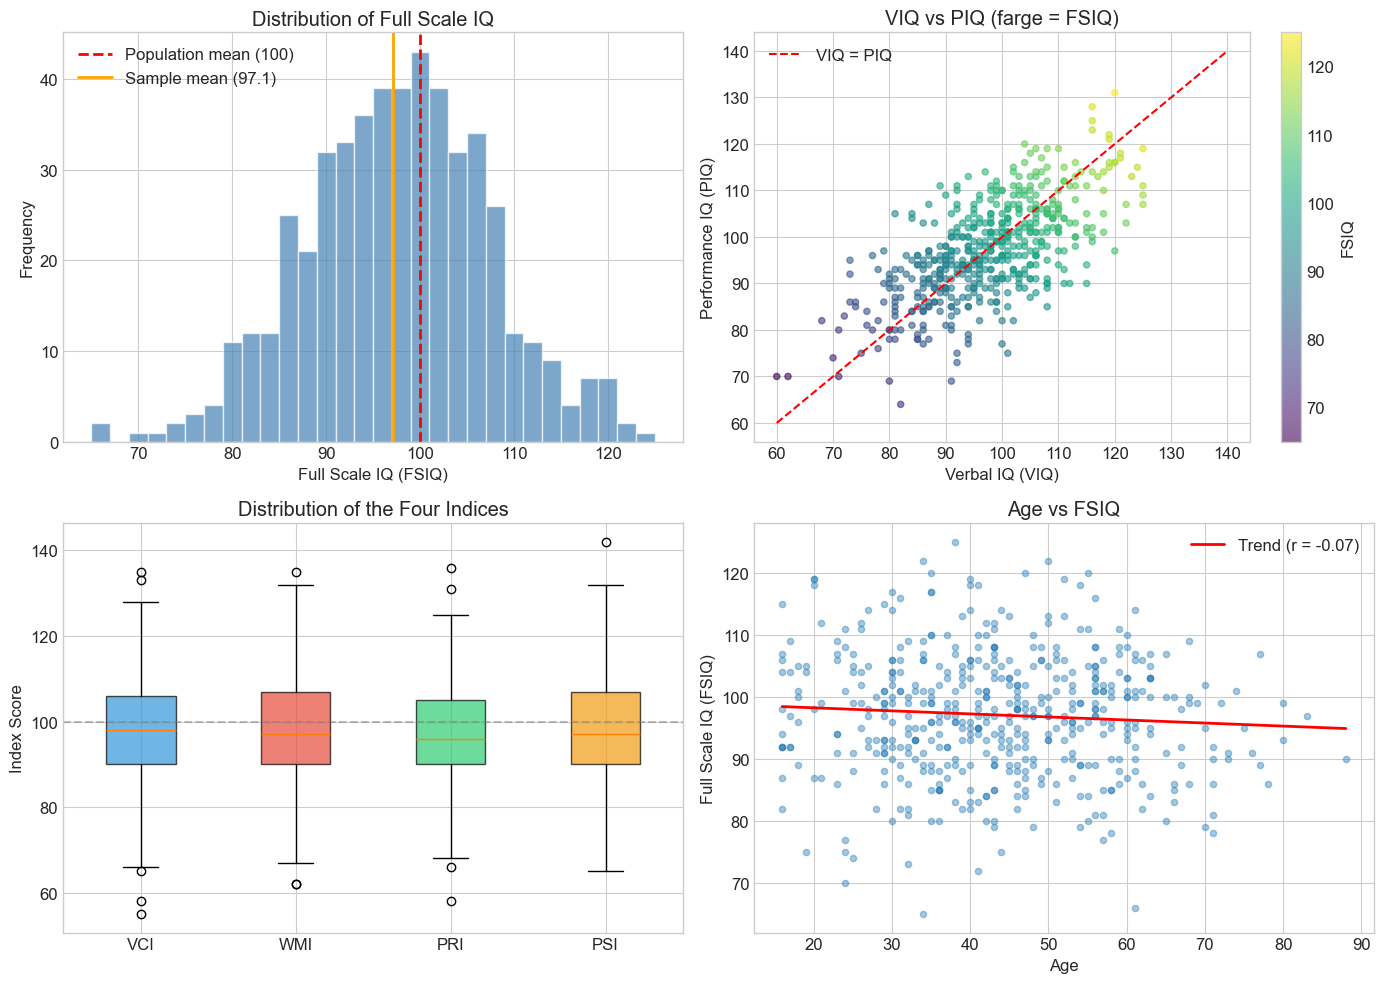


Figure 1: Descriptive overview of IQ data.
  (a) The FSIQ distribution shows an approximately normal distribution, but with mean slightly below 100.
  (b) VIQ vs PIQ shows positive correlation, but with individual variation.
  (c) The four indices have comparable distributions (all with μ < 100).
  (d) FSIQ shows a weak negative trend with age.

  ⚠️ NOTE: In real WAIS-IV, scores would be age-normed, and (d) would show r ≈ 0.
     The negative trend and mean < 100 are artifacts of our simplified simulation
     which does not include age-stratified norm tables. See section 2.1 for details.


In [5]:
# ============================================================================
# VISUALIZATION OF IQ DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. FSIQ Distribution
ax1 = axes[0, 0]
ax1.hist(df['FSIQ'], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(100, color='red', linestyle='--', linewidth=2, label='Population mean (100)')
ax1.axvline(df['FSIQ'].mean(), color='orange', linestyle='-', linewidth=2, label=f'Sample mean ({df["FSIQ"].mean():.1f})')
ax1.set_xlabel('Full Scale IQ (FSIQ)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Full Scale IQ')
ax1.legend()

# 2. VIQ vs PIQ
ax2 = axes[0, 1]
scatter = ax2.scatter(df['VIQ'], df['PIQ'], c=df['FSIQ'], cmap='viridis', alpha=0.6, s=20)
ax2.plot([60, 140], [60, 140], 'r--', label='VIQ = PIQ')
ax2.set_xlabel('Verbal IQ (VIQ)')
ax2.set_ylabel('Performance IQ (PIQ)')
ax2.set_title('VIQ vs PIQ (farge = FSIQ)')
plt.colorbar(scatter, ax=ax2, label='FSIQ')
ax2.legend()

# 3. The four indices
ax3 = axes[1, 0]
index_data = df[['VCI', 'WMI', 'PRI', 'PSI']]
bp = ax3.boxplot([index_data[col] for col in index_data.columns], 
                  labels=['VCI', 'WMI', 'PRI', 'PSI'],
                  patch_artist=True)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylabel('Index Score')
ax3.set_title('Distribution of the Four Indices')

# 4. Age vs FSIQ
ax4 = axes[1, 1]
ax4.scatter(df['Age'], df['FSIQ'], alpha=0.4, s=20)
z = np.polyfit(df['Age'], df['FSIQ'], 1)
p = np.poly1d(z)
ax4.plot(sorted(df['Age']), p(sorted(df['Age'])), 'r-', linewidth=2, label=f'Trend (r = {np.corrcoef(df["Age"], df["FSIQ"])[0,1]:.2f})')
ax4.set_xlabel('Age')
ax4.set_ylabel('Full Scale IQ (FSIQ)')
ax4.set_title('Age vs FSIQ')
ax4.legend()

plt.tight_layout()
plt.show()

print("")
print("Figure 1: Descriptive overview of IQ data.")
print("  (a) The FSIQ distribution shows an approximately normal distribution, but with mean slightly below 100.")
print("  (b) VIQ vs PIQ shows positive correlation, but with individual variation.")
print("  (c) The four indices have comparable distributions (all with μ < 100).")
print("  (d) FSIQ shows a weak negative trend with age.")
print("")
print("  ⚠️ NOTE: In real WAIS-IV, scores would be age-normed, and (d) would show r ≈ 0.")
print("     The negative trend and mean < 100 are artifacts of our simplified simulation")
print("     which does not include age-stratified norm tables. See section 2.1 for details.")


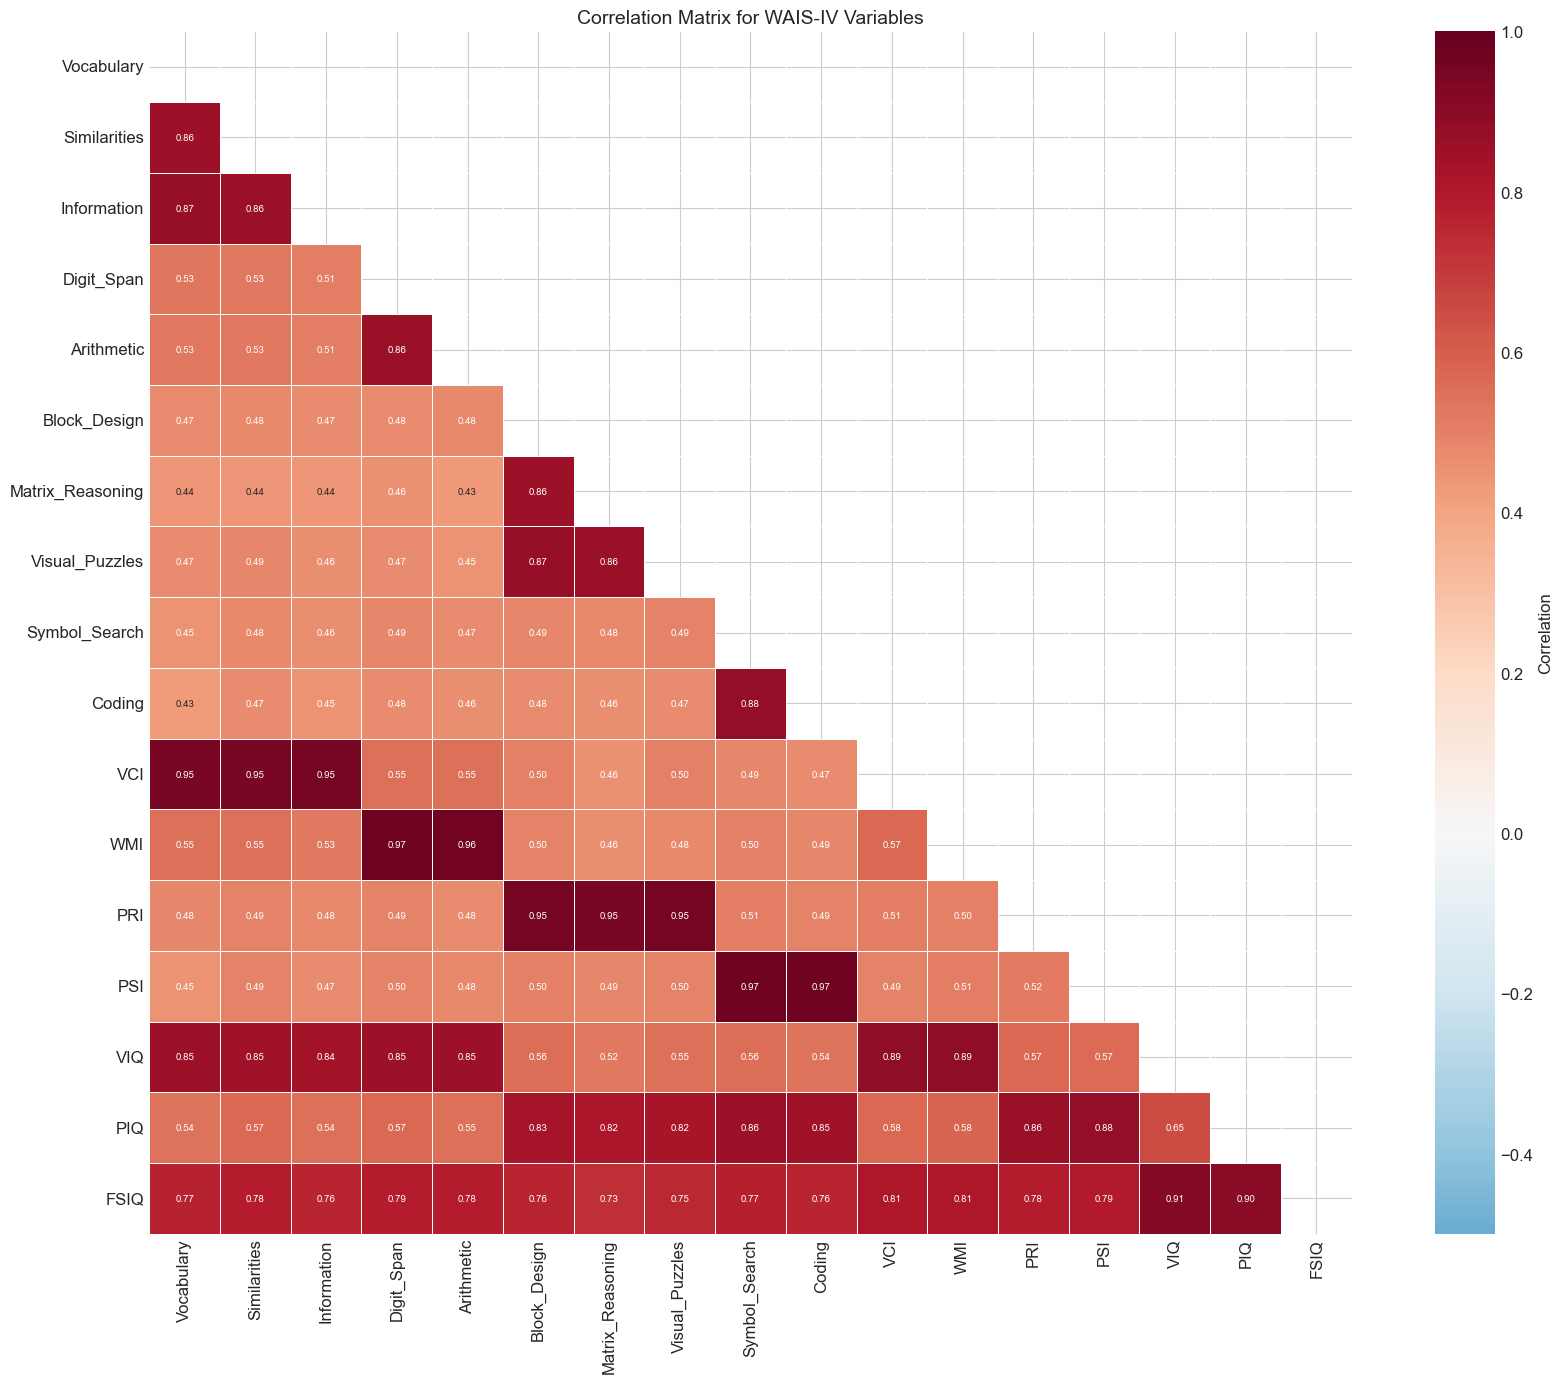


Figure 2: Correlation matrix for all WAIS-IV variables.
  The pattern shows 'positive manifold' - all cognitive measures correlate positively.
  Strongest correlation within each index, as expected.
  This reflects the underlying g-factor (general intelligence).


In [6]:
# ============================================================================
# CORRELATION MATRIX
# ============================================================================

# Select IQ-related variables
corr_vars = ALL_SUBTESTS + ['VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ', 'FSIQ']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-0.5, vmax=1,
            annot_kws={'size': 7},
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix for WAIS-IV Variables', fontsize=14)
plt.tight_layout()
plt.show()

print("")
print("Figure 2: Correlation matrix for all WAIS-IV variables.")
print("  The pattern shows 'positive manifold' - all cognitive measures correlate positively.")
print("  Strongest correlation within each index, as expected.")
print("  This reflects the underlying g-factor (general intelligence).")


---

## 3. Patient Similarity Network (PSN) and Community Detection

### 3.0 What are "Communities" in Graph Theory?

#### 🔬 Graph-Theoretic Definition

In network theory, a **community** (also called: **cluster**, **subgroup**, or **module**) refers to a group of nodes that are *more densely connected to each other* than to the rest of the network.

```
    Community 1              Community 2              Community 3
    ┌─────────────┐          ┌─────────────┐          ┌─────────────┐
    │  ●───●───●  │    ╌╌╌   │  ●───●───●  │    ╌╌╌   │  ●───●───●  │
    │  │ ╲ │ ╱ │  │  weak    │  │ ╲ │ ╱ │  │  weak    │  │ ╲ │ ╱ │  │
    │  ●───●───●  │  edges   │  ●───●───●  │  edges   │  ●───●───●  │
    └─────────────┘          └─────────────┘          └─────────────┘
         many                     many                     many
         strong                   strong                   strong
         edges                    edges                    edges
```

**Formal definition (modularity)**:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $A_{ij}$ = weight of edge between node $i$ and $j$
- $k_i$ = degree (sum of edge weights) for node $i$
- $m$ = total edge weight in the network
- $c_i$ = community membership for node $i$
- $\delta(c_i, c_j) = 1$ if $c_i = c_j$, else 0

**Modularity $Q$** measures how "good" a partition is (higher = better). Typically: $Q > 0.3$ indicates significant community structure.

#### 📝 Terminology Note

| English Term | Alternative Names | Recommended in Medical Context |
|---------|-------------------|------------------------------|
| Community | Cluster, group, module, subgroup | **Patient cluster** or **cognitive subgroup** |
| Community detection | Cluster analysis, group identification | **Subgroup discovery** |
| Modularity | Modularity | Modularity |

> 📝 In this notebook, we use **"community"** consistently to maintain the connection to graph-theoretic literature, but in clinical contexts **"patient cluster"** or **"cognitive subgroup"** would be more intuitive.

---

### ⚠️ Algorithm Choice and Clinical Implications

The choice of community detection algorithm is **not neutral** – different algorithms can yield different patient groupings, with potentially different clinical interpretations.

#### 📊 Overview of Common Algorithms

| Algorithm | Principle | Strengths | Weaknesses |
|-----------|----------|---------|-----------|
| **Louvain** | Hierarchical modularity optimization | Fast, scalable, yields high $Q$ | May miss small communities |
| **Leiden** | Improved Louvain | Guaranteed connected communities | Newer, less widespread |
| **Label Propagation** | Nodes "infect" neighbors with label | Very fast | Unstable, non-deterministic |
| **Spectral Clustering** | Eigenvalue decomposition of Laplacian | Mathematically elegant | Requires number of clusters as input |
| **Girvan-Newman** | Removes edges with high "betweenness" | Hierarchical, intuitive | Very slow on large networks |
| **Infomap** | Minimizes description length of random walks | Good for flow networks | Less intuitive |
| **Stochastic Block Model** | Statistical inference | Probabilistic, handles uncertainty | Computationally expensive |

#### 🏥 Clinical Consequences of Algorithm Choice

<details>
<summary>🔍 <b>Click for detailed analysis of clinical implications</b></summary>

##### Scenario 1: Number of Communities

| Algorithm | Number of Communities | Clinical Interpretation |
|-----------|-------------------|------------------|
| Louvain (high resolution) | 2-3 | Coarse division: "high vs. low IQ" |
| Louvain (low resolution) | 8-12 | Fine division: specific profiles |
| K-means (k=4) | 4 | Predetermined: matches the indices? |

**Consequence**: With few communities we risk missing important subgroups. With many communities we risk overfitting and noise.

##### Scenario 2: Patient X Ends Up in Different Communities

```
Algorithm A:  Patient X → Community "Verbal strength"
Algorithm B:  Patient X → Community "Working memory weakness"  
Algorithm C:  Patient X → Community "Average profile"
```

**Clinical Implications**:
- **Rehabilitation**: Which strengths should we build on?
- **Career guidance**: Verbal job or visual job?
- **Diagnosis**: Is this a specific difficulty or normal variation?

##### Scenario 3: Stability Over Time

A patient is tested at T1 (before treatment) and T2 (after treatment):

| Algorithm | T1 Community | T2 Community | Interpretation |
|-----------|--------------|--------------|----------|
| Stable algorithm | A | A | No change |
| Unstable algorithm | A | B | False positive "improvement"? |

**Consequence**: Unstable algorithms can produce false positive or negative treatment effects.

##### Recommendations for Clinical Use

1. **Run multiple algorithms**: Compare results, look for consensus
2. **Report uncertainty**: "Patient X is most similar to group A, but also B"
3. **Use domain expertise**: Does the grouping make clinical sense?
4. **Validate externally**: Do communities correlate with known diagnoses/outcomes?
5. **Be transparent**: Document algorithm and parameter choices

</details>

#### 💡 Our Approach in This Notebook

We use the **Louvain algorithm** because:
- ✅ Fast and scalable
- ✅ Provides modularity score ($Q$) as quality measure
- ✅ Well-established in medical network research
- ✅ Implemented in the `python-louvain` / `community` package

**Important**: The results should be interpreted as *one possible partition*, not the "true" subgroup structure!

---

Now we will build patient similarity networks at **three different granularity levels**:

| Level | Variables | Number of Dimensions | Description |
|------|-----------|-------------------|-------------|
| **Item** | All 10 core tests | 10 | Most detailed, captures subtle profiles |
| **Domain** | VCI, WMI, PRI, PSI | 4 | Intermediate, focus on cognitive domains |
| **VIQ/PIQ** | VIQ, PIQ | 2 | Coarsest, separates verbal from non-verbal intelligence |

### 3.1 Helper Functions


### 3.1 Similarity: How to Measure "Likeness" Between Patients?

#### 🔬 The Concept of Similarity

Before we can build a patient similarity network, we must define what "similarity" means. This is a **critical methodological choice** that affects all downstream analyses.

```
     PATIENT A                    PATIENT B
   ┌───────────────┐            ┌───────────────┐
   │ VCI: 110      │            │ VCI: 108      │
   │ WMI: 95       │    ?       │ WMI: 98       │
   │ PRI: 100      │  ════►     │ PRI: 102      │   How SIMILAR are they?
   │ PSI: 85       │ Similarity?│ PSI: 88       │
   └───────────────┘            └───────────────┘
```

#### 📏 From Distance to Similarity: A Two-Step Process

**Step 1: Calculate distance (dissimilarity)**

We use **Euclidean distance** in the scaled feature space:

$$d_{ij} = \sqrt{\sum_{k=1}^{p} (x_{ik} - x_{jk})^2}$$

where $x_{ik}$ is patient $i$'s score on variable $k$ (after standardization).

**Step 2: Convert to similarity with Gaussian kernel**

$$s_{ij} = \exp\left(-\frac{d_{ij}^2}{2\sigma^2}\right)$$

where $\sigma$ is a bandwidth parameter (we use mean distance).

```
        Distance (d)                    Similarity (s)
        
    0 ─────────────────►         1.0 ──┐
                                       │  ⟍
    σ ─────────────────►         0.6 ──┤     ⟍
                                       │        ⟍
   2σ ─────────────────►         0.1 ──┤           ⟍____
                                       │
   3σ ─────────────────►        ≈0.0 ──┘
```

#### ⚠️ Critical Methodological Choices and Implications

<details>
<summary><b>🔍 Deep Dive: Choice of Distance Measure</b> (click to expand)</summary>

| Distance Measure | Formula | Advantages | Disadvantages | When to use? |
|-------------|--------|----------|---------|------------|
| **Euclidean** | $\sqrt{\sum(x_i - y_i)^2}$ | Intuitive, geometrically interpretable | Sensitive to scale, "curse of dimensionality" | Standard choice, works well with standardized data |
| **Manhattan** | $\sum\|x_i - y_i\|$ | Robust to outliers | Less common | When extreme values are important |
| **Cosine** | $1 - \frac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|}$ | Scale-independent | Ignores absolute level | When *profile* is more important than *level* |
| **Mahalanobis** | $\sqrt{(\mathbf{x}-\mathbf{y})^T \Sigma^{-1} (\mathbf{x}-\mathbf{y})}$ | Accounts for correlations | Requires stable covariance matrix | Correlated variables |
| **Correlation** | $1 - \text{corr}(x, y)$ | Captures profile similarity | Sensitive to few variables | Profile comparison |

**Important observation for WAIS-IV:**
- With **Euclidean distance**: Patients with similar *level* AND *profile* are alike
- With **Cosine/Correlation**: Patients with similar *profile* are alike (regardless of level)

**Example:**
```
Patient A: VCI=120, WMI=100, PRI=110, PSI=90   (high, uneven)
Patient B: VCI=100, WMI= 83, PRI= 92, PSI=75   (lower, same profile)
Patient C: VCI=118, WMI=102, PRI=108, PSI=92   (high, even)

Euclidean: A is most similar to C (similar level)
Cosine:    A is most similar to B (similar profile shape)
```

</details>

<details>
<summary><b>🔍 Deep Dive: Choice of Kernel Function and σ</b></summary>

**Why Gaussian kernel?**
1. Gives values between 0 and 1 (practical for weights)
2. Monotonically decreasing with distance
3. Smooth transition (no hard thresholds)
4. Well-established in the literature (radial basis functions)

**Alternative kernel functions:**

| Kernel | Formula | Property |
|--------|--------|----------|
| **Gaussian** | $e^{-d^2/2\sigma^2}$ | Smooth, infinite range |
| **Linear** | $\max(0, 1-d/\sigma)$ | Simple, finite range |
| **Polynomial** | $(1 + d)^{-p}$ | Adjustable tail |
| **Cosine** | $\cos(\pi d / 2\sigma)$ for $d < \sigma$ | Compact support |

**Choice of σ (bandwidth):**
- **Too small σ**: Only very close patients connect → fragmented network
- **Too large σ**: All patients alike → no structure
- **Our approach**: $\sigma = \bar{d}$ (mean distance) → adaptive scaling

</details>

<details>
<summary><b>🔍 Deep Dive: The Importance of Standardization</b></summary>

**Before standardization:**
```
VCI:  μ=100, σ=15, range ≈ [55, 145]
PSI:  μ=100, σ=15, range ≈ [55, 145]  (same scale)

But what if we had:
Age:  μ=45, σ=15, range ≈ [16, 90]   (years)
FSIQ: μ=100, σ=10, range ≈ [60, 140] (points)
```

Without standardization, age would dominate the distance calculation!

**StandardScaler:**
$$z_i = \frac{x_i - \mu}{\sigma}$$

After standardization, all variables have μ=0 and σ=1 → equal contribution.

</details>

#### 📊 Implications for PSN

| Choice | Consequence for PSN | Clinical Implication |
|------|-------------------|---------------------|
| **Euclidean + Gaussian** | Patients with similar level AND profile connect | Groups by overall functional level |
| **Cosine similarity** | Patients with similar profile shape connect | Groups by strength/weakness pattern |
| **High σ** | Denser network, fewer distinct groups | Coarser patient categories |
| **Low σ** | Sparser network, many small groups | Finer differentiation |

> 💡 **In this notebook, we use Euclidean distance + Gaussian kernel + adaptive σ**, which is a good starting point. For clinical use, one should consider whether *profile* or *level* is most important.


In [7]:
# ============================================================================
# HELPER FUNCTIONS FOR PSN
# ============================================================================

def create_similarity_matrix(data, metric='euclidean'):
    """
    Calculate similarity matrix from feature matrix.
    
    Methodological choices (see section 3.1 for justification):
    1. Standardization: z = (x - μ) / σ → all variables contribute equally
    2. Distance measure: Euclidean distance d_ij = sqrt(Σ(x_i - x_j)²)
    3. Similarity conversion: Gaussian kernel s_ij = exp(-d²/(2σ²))
    4. Bandwidth σ: Adaptive (mean distance)
    
    Parameters:
    -----------
    data : array-like, shape (n_samples, n_features)
        Feature matrix (e.g., VCI, WMI, PRI, PSI for each patient)
    metric : str
        Distance measure ('euclidean', 'manhattan', 'cosine', etc.)
    
    Returns:
    -----------
    similarity_matrix : ndarray, shape (n_samples, n_samples)
        Symmetric similarity matrix with s_ij ∈ [0, 1]
    """
    # Step 1: Standardize data (μ=0, σ=1)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Step 2: Calculate pairwise distances
    distances = pdist(scaled_data, metric=metric)
    dist_matrix = squareform(distances)
    
    # Step 3: Convert to similarities with Gaussian kernel
    sigma = np.mean(distances) + 1e-8  # Adaptive bandwidth
    similarity_matrix = np.exp(-dist_matrix**2 / (2 * sigma**2))
    
    return similarity_matrix


def create_psn(similarity_matrix, threshold=None, k_nearest=10):
    """
    Build patient similarity network from similarity matrix.
    
    Parameters:
    - threshold: Minimum similarity to include edge (None = use k_nearest)
    - k_nearest: Number of nearest neighbors to connect to
    """
    n = similarity_matrix.shape[0]
    G = nx.Graph()
    
    # Add nodes
    G.add_nodes_from(range(n))
    
    # Add edges
    for i in range(n):
        # Find k nearest neighbors
        neighbors = np.argsort(similarity_matrix[i])[-k_nearest-1:-1]  # Exclude self
        
        for j in neighbors:
            if i != j:
                weight = similarity_matrix[i, j]
                if threshold is None or weight >= threshold:
                    G.add_edge(i, j, weight=weight)
    
    return G


def detect_communities(G):
    """
    Perform community detection using the Louvain method.
    """
    if COMMUNITY_AVAILABLE:
        partition = community_louvain.best_partition(G)
        modularity = community_louvain.modularity(partition, G)
    else:
        # Fallback til NetworkX
        communities = nx.community.greedy_modularity_communities(G)
        partition = {}
        for i, comm in enumerate(communities):
            for node in comm:
                partition[node] = i
        modularity = nx.community.modularity(G, communities)
    
    return partition, modularity


def visualize_psn(G, partition, df, title, ax=None, node_color_var=None):
    """
    Visualize patient similarity network.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 10))
    
    # Layout
    pos = nx.spring_layout(G, k=1/np.sqrt(G.number_of_nodes()), iterations=50, seed=42)
    
    # Colors based on community
    n_communities = len(set(partition.values()))
    colors = plt.cm.Set3(np.linspace(0, 1, max(12, n_communities)))
    node_colors = [colors[partition[node]] for node in G.nodes()]
    
    # Node size based on degree
    degrees = dict(G.degree())
    node_sizes = [50 + 10 * degrees[node] for node in G.nodes()]
    
    # Draw edges
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.5, ax=ax)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.7, ax=ax)
    
    ax.set_title(title)
    ax.axis('off')
    
    return pos


print("✓ Helper functions defined!")


✓ Helper functions defined!


### 3.2 Build PSN at Three Levels


In [8]:
# ============================================================================
# BUILD PSN AT THREE GRANULARITY LEVELS
# ============================================================================

# Define features for each level
features_item = ALL_SUBTESTS  # 13 subtests
features_domain = ['VCI', 'WMI', 'PRI', 'PSI']  # 4 indices
features_viq_piq = ['VIQ', 'PIQ']  # 2 composite scores

# Calculate similarity matrices
print("Calculating similarity matrices...")
sim_item = create_similarity_matrix(df[features_item])
sim_domain = create_similarity_matrix(df[features_domain])
sim_viq_piq = create_similarity_matrix(df[features_viq_piq])

# Build networks
print("Building networks...")
G_item = create_psn(sim_item, k_nearest=15)
G_domain = create_psn(sim_domain, k_nearest=15)
G_viq_piq = create_psn(sim_viq_piq, k_nearest=15)

# Community detection
print("Performing community detection...")
partition_item, mod_item = detect_communities(G_item)
partition_domain, mod_domain = detect_communities(G_domain)
partition_viq_piq, mod_viq_piq = detect_communities(G_viq_piq)

# Summary
print("\n" + "="*60)
print("NETWORK STATISTICS")
print("="*60)

networks = {
    'Item level (13 dim)': (G_item, partition_item, mod_item),
    'Domain level (4 dim)': (G_domain, partition_domain, mod_domain),
    'VIQ/PIQ level (2 dim)': (G_viq_piq, partition_viq_piq, mod_viq_piq)
}

for name, (G, part, mod) in networks.items():
    n_comm = len(set(part.values()))
    density = nx.density(G)
    avg_clustering = nx.average_clustering(G)
    
    print(f"\n{name}:")
    print(f"  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"  Density: {density:.3f}")
    print(f"  Average clustering: {avg_clustering:.3f}")
    print(f"  Number of communities: {n_comm}")
    print(f"  Modularity: {mod:.3f}")


Calculating similarity matrices...
Building networks...
Performing community detection...

NETWORK STATISTICS

Item level (13 dim):
  Nodes: 500, Edges: 5158
  Density: 0.041
  Average clustering: 0.408
  Number of communities: 8
  Modularity: 0.567

Domain level (4 dim):
  Nodes: 500, Edges: 5012
  Density: 0.040
  Average clustering: 0.443
  Number of communities: 9
  Modularity: 0.593

VIQ/PIQ level (2 dim):
  Nodes: 500, Edges: 4520
  Density: 0.036
  Average clustering: 0.587
  Number of communities: 10
  Modularity: 0.736


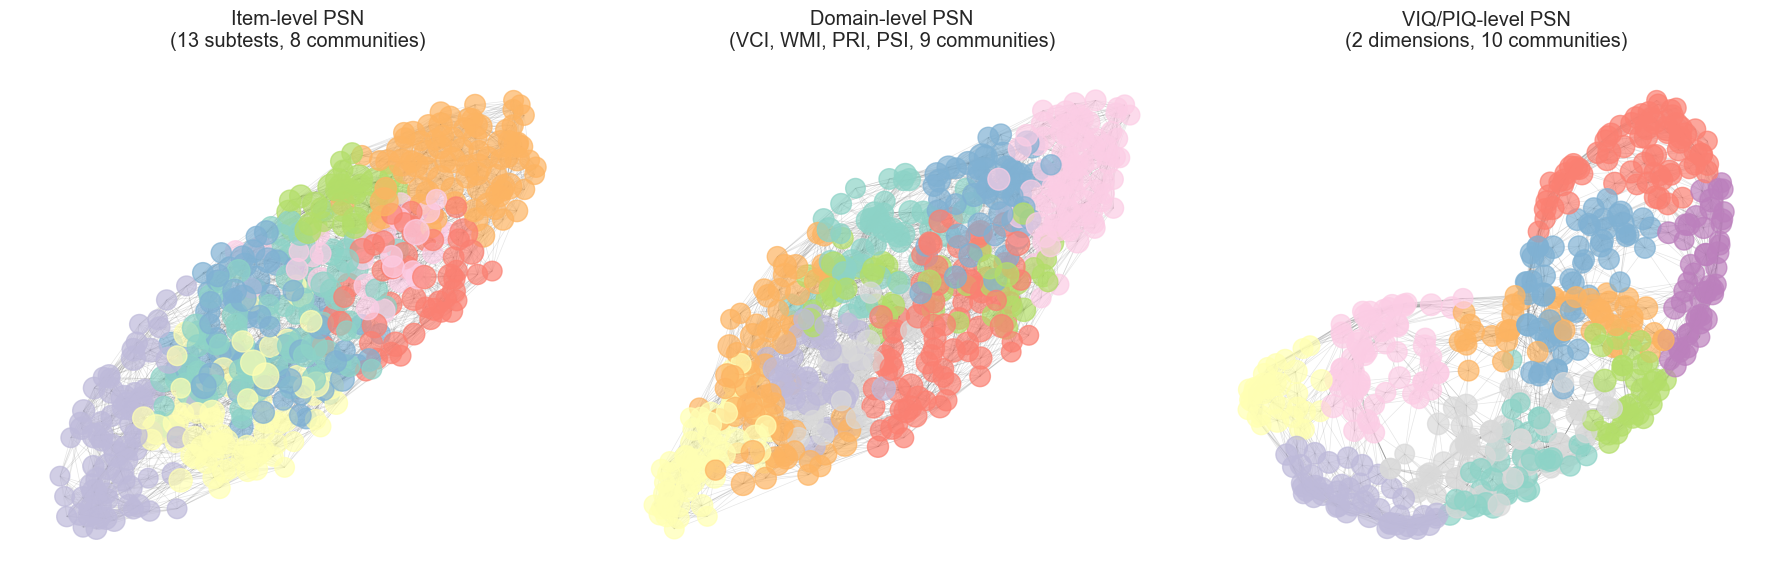


Figure 3: Patient similarity networks at three granularity levels.
  Colors represent different communities (subgroups).
  Node size reflects number of connections (degree).
  Higher granularity (item level) yields more and more nuanced communities.
  Lower granularity (VIQ/PIQ) yields coarser grouping.


In [9]:
# ============================================================================
# VISUALIZATION OF THE THREE NETWORKS
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

visualize_psn(G_item, partition_item, df, 
              f'Item-level PSN\n(13 subtests, {len(set(partition_item.values()))} communities)', 
              ax=axes[0])

visualize_psn(G_domain, partition_domain, df, 
              f'Domain-level PSN\n(VCI, WMI, PRI, PSI, {len(set(partition_domain.values()))} communities)', 
              ax=axes[1])

visualize_psn(G_viq_piq, partition_viq_piq, df, 
              f'VIQ/PIQ-level PSN\n(2 dimensions, {len(set(partition_viq_piq.values()))} communities)', 
              ax=axes[2])

plt.tight_layout()
plt.show()

print("")
print("Figure 3: Patient similarity networks at three granularity levels.")
print("  Colors represent different communities (subgroups).")
print("  Node size reflects number of connections (degree).")
print("  Higher granularity (item level) yields more and more nuanced communities.")
print("  Lower granularity (VIQ/PIQ) yields coarser grouping.")


### 3.3 Analysis of Communities

Let's examine what characterizes the different subgroups.


ANALYSIS OF COMMUNITIES (DOMAIN-LEVEL PSN)

Community profiles:
                   N   Age   FSIQ    VCI    WMI    PRI    PSI    VIQ    PIQ
Community_Domain                                                           
0                 48  42.9   95.8   97.0   97.3  101.7   88.8   97.0   95.0
1                 58  39.9  112.9  111.2  112.6  115.3  114.3  111.7  114.6
2                 38  43.2  102.5   95.7  103.2  106.4  106.5   99.2  106.2
3                 81  41.4   95.8   91.6   97.9   92.3  103.0   94.6   97.4
4                 50  45.0   89.4   93.8   82.4   94.3   88.9   87.9   91.4
5                 68  46.2  105.5  111.3  109.2  102.4  101.0  110.0  101.5
6                 47  45.0   95.4  104.3  100.2   88.2   91.1  102.0   89.4
7                 82  46.0   82.6   81.4   84.5   82.3   84.3   82.7   83.1
8                 28  43.0  101.6  107.1   91.6  102.3  107.6   99.1  104.7


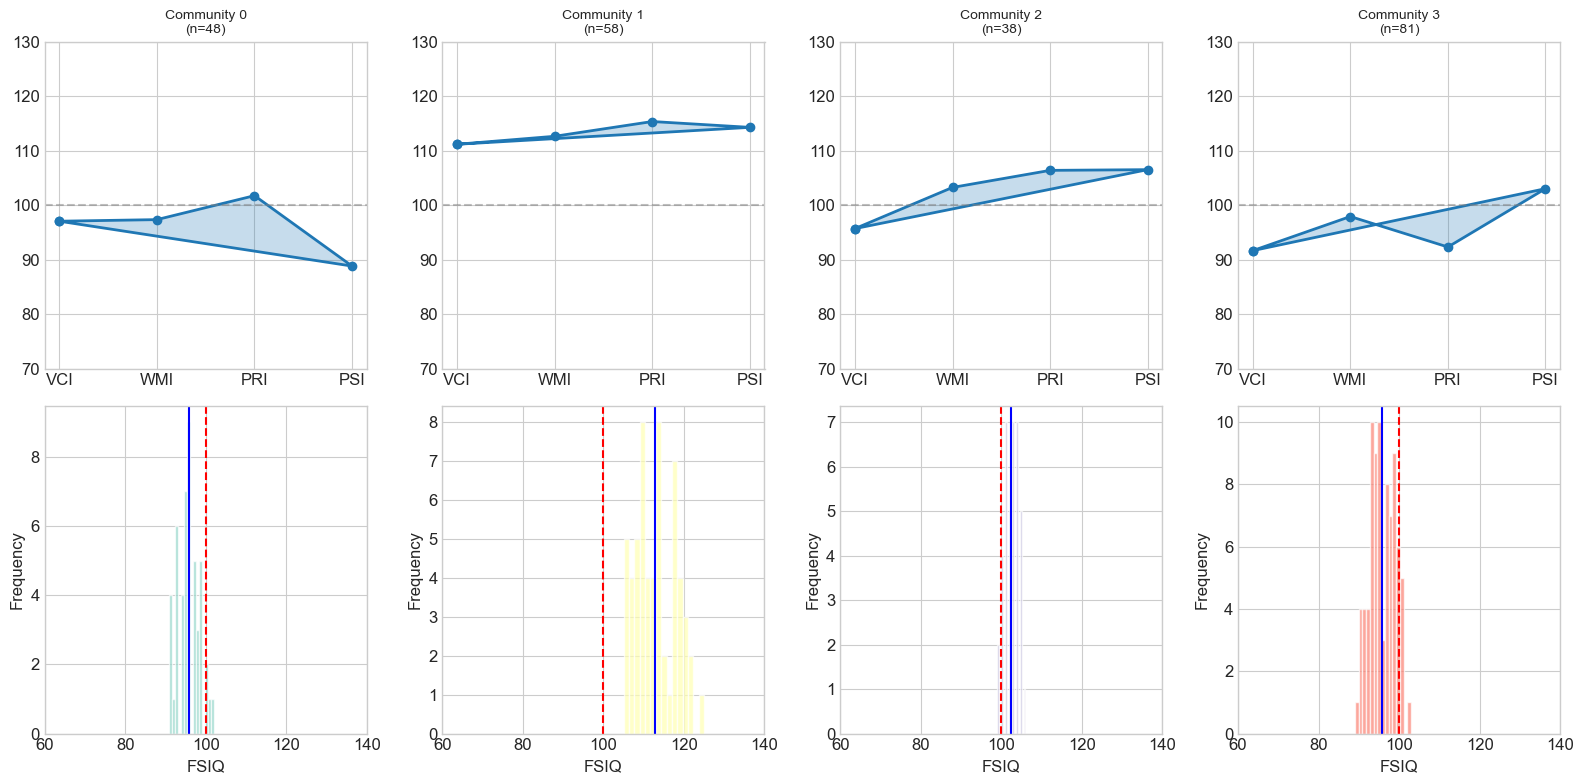


Figure 4: Cognitive profiles for the different communities.
  Upper row: Radar profiles show mean score on each index.
  Lower row: FSIQ distributions with population mean (red) and community mean (blue).
  Note: Communities can represent different cognitive profiles, not just IQ level!


In [10]:
# ============================================================================
# COMMUNITY ANALYSIS (DOMAIN LEVEL)
# ============================================================================

# Add community membership to dataframe
df['Community_Domain'] = [partition_domain[i] for i in range(len(df))]

# Analyze each community
print("="*70)
print("ANALYSIS OF COMMUNITIES (DOMAIN-LEVEL PSN)")
print("="*70)

# Statistics per community
community_stats = df.groupby('Community_Domain').agg({
    'ID': 'count',
    'Age': 'mean',
    'FSIQ': 'mean',
    'VCI': 'mean',
    'WMI': 'mean',
    'PRI': 'mean',
    'PSI': 'mean',
    'VIQ': 'mean',
    'PIQ': 'mean'
}).round(1)

community_stats.columns = ['N', 'Age', 'FSIQ', 'VCI', 'WMI', 'PRI', 'PSI', 'VIQ', 'PIQ']
print("\nCommunity profiles:")
print(community_stats)

# Visualize community profiles
n_communities = len(set(partition_domain.values()))
fig, axes = plt.subplots(2, min(4, n_communities), figsize=(16, 8))
if n_communities < 4:
    axes = np.array(axes).reshape(2, -1)

for i, comm in enumerate(sorted(set(partition_domain.values()))):
    if i >= 4:  # Max 4 communities shown
        break
    
    comm_df = df[df['Community_Domain'] == comm]
    
    # Upper row: Radar profile of indices
    ax1 = axes[0, i]
    categories = ['VCI', 'WMI', 'PRI', 'PSI']
    values = [comm_df[cat].mean() for cat in categories]
    values += values[:1]  # Close the circle
    
    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    ax1.fill(angles, values, alpha=0.25)
    ax1.plot(angles, values, 'o-', linewidth=2)
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(categories)
    ax1.set_ylim(70, 130)
    ax1.axhline(100, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f'Community {comm}\n(n={len(comm_df)})', fontsize=10)
    
    # Lower row: FSIQ distribution
    ax2 = axes[1, i]
    ax2.hist(comm_df['FSIQ'], bins=15, color=plt.cm.Set3(i/10), edgecolor='white', alpha=0.7)
    ax2.axvline(100, color='red', linestyle='--')
    ax2.axvline(comm_df['FSIQ'].mean(), color='blue', linestyle='-')
    ax2.set_xlabel('FSIQ')
    ax2.set_ylabel('Frequency')
    ax2.set_xlim(60, 140)

plt.tight_layout()
plt.show()

print("")
print("Figure 4: Cognitive profiles for the different communities.")
print("  Upper row: Radar profiles show mean score on each index.")
print("  Lower row: FSIQ distributions with population mean (red) and community mean (blue).")
print("  Note: Communities can represent different cognitive profiles, not just IQ level!")


### 3.4 Key Insight: Same FSIQ ≠ Same Cognitive Profile

One of the most important insights from PSN analysis is that **Full Scale IQ (FSIQ) alone is insufficient** to characterize cognitive function. Two patients with identical FSIQ can have fundamentally different strengths and weaknesses.

```
   Patient A (FSIQ = 100)          Patient B (FSIQ = 100)
   ┌─────────────────────┐         ┌─────────────────────┐
   │  VCI: 115  ★★★★★    │         │  VCI:  85  ★★       │
   │  WMI: 110  ★★★★     │         │  WMI:  90  ★★★      │
   │  PRI:  85  ★★       │         │  PRI: 115  ★★★★★    │
   │  PSI:  90  ★★★      │         │  PSI: 110  ★★★★     │
   └─────────────────────┘         └─────────────────────┘
        "Verbal profile"                "Visual profile"
        Community 1                    Community 2
```

**Clinical relevance:**
- Patient A: Would likely succeed in careers with extensive verbal communication (journalist, teacher, therapist)
- Patient B: Would likely succeed in careers with visuospatial demands (engineer, architect, surgeon)

**PSN reveals this** by grouping based on the entire profile, not just FSIQ!


KEY INSIGHT: SAME FSIQ CAN BELONG TO DIFFERENT COMMUNITIES

FSIQ statistics per community:
                  min  max   mean  std
Community_Domain                      
0                  91  102   95.8  2.7
1                 105  125  112.9  5.0
2                  99  106  102.5  1.9
3                  89  103   95.8  3.3
4                  81   96   89.4  2.9
5                  97  116  105.5  3.6
6                  88  102   95.4  4.1
7                  65   91   82.6  5.2
8                  97  107  101.6  2.9

📊 Patients with 'normal' FSIQ (95-105): n=207

Distribution across communities:
Community_Domain
0    33
1     1
2    37
3    49
4     2
5    31
6    29
8    25
Name: count, dtype: int64


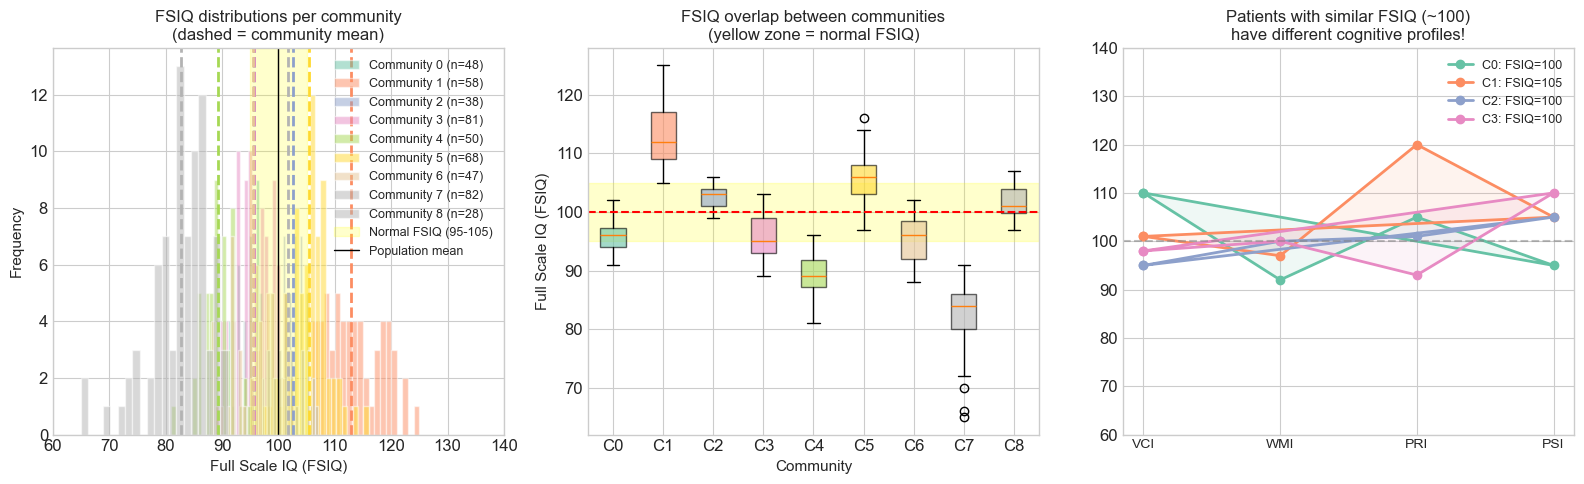


EXAMPLE: Two patients with nearly identical FSIQ

Variable        Patient A       Patient B       Difference
-------------------------------------------------------
Community       0               1              
FSIQ            100             105             5
-------------------------------------------------------
VCI             110             101             ↑ 9
WMI             92              97              ↓ 5
PRI             105             120             ↓ 15
PSI             95              105             ↓ 10
-------------------------------------------------------
VIQ             101             99             
PIQ             100             112            

💡 KEY POINT:
   → Full Scale IQ (FSIQ) alone gives an incomplete picture
   → Patients with similar FSIQ can have very different cognitive profiles
   → PSN groups based on the ENTIRE profile, not just FSIQ
   → This enables precision neuropsychology!


In [11]:
# ============================================================================
# SAME FSIQ - DIFFERENT COMMUNITIES
# ============================================================================
# Illustrates that patients with similar Full Scale IQ can belong to different communities

print("="*70)
print("KEY INSIGHT: SAME FSIQ CAN BELONG TO DIFFERENT COMMUNITIES")
print("="*70)

# Find FSIQ range with overlap between communities
fsiq_ranges = df.groupby('Community_Domain')['FSIQ'].agg(['min', 'max', 'mean', 'std'])
print("\nFSIQ statistics per community:")
print(fsiq_ranges.round(1))

# Find patients with FSIQ near the population mean (95-105)
normal_iq_mask = (df['FSIQ'] >= 95) & (df['FSIQ'] <= 105)
normal_iq_df = df[normal_iq_mask]

print(f"\n📊 Patients with 'normal' FSIQ (95-105): n={len(normal_iq_df)}")
print("\nDistribution across communities:")
print(normal_iq_df['Community_Domain'].value_counts().sort_index())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Overlapping FSIQ distributions
ax1 = axes[0]
communities = sorted(df['Community_Domain'].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(communities)))

for i, comm in enumerate(communities):
    comm_data = df[df['Community_Domain'] == comm]['FSIQ']
    ax1.hist(comm_data, bins=20, alpha=0.5, label=f'Community {comm} (n={len(comm_data)})', 
             color=colors[i], edgecolor='white')
    ax1.axvline(comm_data.mean(), color=colors[i], linestyle='--', linewidth=2)

ax1.axvspan(95, 105, alpha=0.2, color='yellow', label='Normal FSIQ (95-105)')
ax1.axvline(100, color='black', linestyle='-', linewidth=1, label='Population mean')
ax1.set_xlabel('Full Scale IQ (FSIQ)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('FSIQ distributions per community\n(dashed = community mean)', fontsize=12)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(60, 140)

# 2. Boxplot av FSIQ per community
ax2 = axes[1]
bp = ax2.boxplot([df[df['Community_Domain']==c]['FSIQ'] for c in communities],
                  labels=[f'C{c}' for c in communities], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(100, color='red', linestyle='--', label='Population mean')
ax2.axhspan(95, 105, alpha=0.2, color='yellow')
ax2.set_xlabel('Community', fontsize=11)
ax2.set_ylabel('Full Scale IQ (FSIQ)', fontsize=11)
ax2.set_title('FSIQ overlap between communities\n(yellow zone = normal FSIQ)', fontsize=12)

# 3. Cognitive profiles for patients with FSIQ ~ 100 in different communities
ax3 = axes[2]

# Find a patient from each community with FSIQ near 100
categories = ['VCI', 'WMI', 'PRI', 'PSI']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

example_patients = []
for comm in communities[:4]:  # Max 4 communities
    comm_normal = normal_iq_df[normal_iq_df['Community_Domain'] == comm]
    if len(comm_normal) > 0:
        # Select patient closest to FSIQ=100
        idx = (comm_normal['FSIQ'] - 100).abs().idxmin()
        patient = comm_normal.loc[idx]
        example_patients.append((comm, patient))
        
        values = [patient[cat] for cat in categories]
        values += values[:1]
        ax3.plot(angles, values, 'o-', linewidth=2, 
                 label=f"C{comm}: FSIQ={int(patient['FSIQ'])}", color=colors[comm])
        ax3.fill(angles, values, alpha=0.1, color=colors[comm])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=10)
ax3.set_ylim(60, 140)
ax3.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Patients with similar FSIQ (~100)\nhave different cognitive profiles!', fontsize=12)
ax3.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Concrete example
print("\n" + "="*70)
print("EXAMPLE: Two patients with nearly identical FSIQ")
print("="*70)

if len(example_patients) >= 2:
    p1 = example_patients[0][1]
    p2 = example_patients[1][1]
    
    print(f"\n{'Variable':<15} {'Patient A':<15} {'Patient B':<15} {'Difference':<10}")
    print("-"*55)
    print(f"{'Community':<15} {example_patients[0][0]:<15} {example_patients[1][0]:<15}")
    print(f"{'FSIQ':<15} {int(p1['FSIQ']):<15} {int(p2['FSIQ']):<15} {abs(p1['FSIQ']-p2['FSIQ']):.0f}")
    print("-"*55)
    for var in ['VCI', 'WMI', 'PRI', 'PSI']:
        diff = p1[var] - p2[var]
        arrow = "↑" if diff > 0 else "↓" if diff < 0 else "="
        print(f"{var:<15} {int(p1[var]):<15} {int(p2[var]):<15} {arrow} {abs(diff):.0f}")
    print("-"*55)
    print(f"{'VIQ':<15} {int(p1['VIQ']):<15} {int(p2['VIQ']):<15}")
    print(f"{'PIQ':<15} {int(p1['PIQ']):<15} {int(p2['PIQ']):<15}")

print("\n💡 KEY POINT:")
print("   → Full Scale IQ (FSIQ) alone gives an incomplete picture")
print("   → Patients with similar FSIQ can have very different cognitive profiles")
print("   → PSN groups based on the ENTIRE profile, not just FSIQ")
print("   → This enables precision neuropsychology!")


---

## 4. Clinical Applications

### 4.1 Case: Identification of Similar Patients

Imagine a patient with specific strengths and weaknesses. How can PSN help with precision neuropsychology?


In [12]:
# ============================================================================
# CASE STUDY: FIND SIMILAR PATIENTS
# ============================================================================

def find_similar_patients(target_idx, G, similarity_matrix, df, n_similar=5):
    """
    Find the most similar patients based on PSN.
    """
    # Get neighbors in the network
    if target_idx in G:
        neighbors = list(G.neighbors(target_idx))
    else:
        neighbors = []
    
    # Sort by similarity
    similarities = [(n, similarity_matrix[target_idx, n]) for n in neighbors]
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    return similarities[:n_similar]


def display_patient_profile(idx, df):
    """
    Display the profile of a patient.
    """
    patient = df.iloc[idx]
    
    print(f"\n{'='*50}")
    print(f"PATIENT: {patient['ID']}")
    print(f"{'='*50}")
    print(f"Age: {patient['Age']}, Gender: {patient['Gender']}, Education: {patient['Education']}")
    print(f"\nIQ scores:")
    print(f"  FSIQ: {patient['FSIQ']} (VIQ: {patient['VIQ']}, PIQ: {patient['PIQ']})")
    print(f"  Indices: VCI={patient['VCI']}, WMI={patient['WMI']}, PRI={patient['PRI']}, PSI={patient['PSI']}")
    
    # Identify strengths and weaknesses
    indices = ['VCI', 'WMI', 'PRI', 'PSI']
    index_values = {idx: patient[idx] for idx in indices}
    mean_index = np.mean(list(index_values.values()))
    
    strengths = [k for k, v in index_values.items() if v > mean_index + 10]
    weaknesses = [k for k, v in index_values.items() if v < mean_index - 10]
    
    if strengths:
        print(f"\n  ✓ Relative strengths: {', '.join(strengths)}")
    if weaknesses:
        print(f"  ✗ Relative weaknesses: {', '.join(weaknesses)}")
    
    return patient


# Select a "target patient" with an interesting profile (e.g. low PSI, high VCI)
# Find a patient with large spread between the indices
df['Index_Spread'] = df[['VCI', 'WMI', 'PRI', 'PSI']].std(axis=1)
target_idx = df['Index_Spread'].idxmax()  # Patient with largest spread

# Show the target patient
target_patient = display_patient_profile(target_idx, df)

# Find similar patients
print("\n" + "-"*50)
print("SIMILAR PATIENTS (based on domain-level PSN):")
print("-"*50)

similar = find_similar_patients(target_idx, G_domain, sim_domain, df, n_similar=5)

for i, (sim_idx, sim_score) in enumerate(similar, 1):
    sim_patient = df.iloc[sim_idx]
    print(f"\n{i}. {sim_patient['ID']} (similarity: {sim_score:.3f})")
    print(f"   FSIQ: {sim_patient['FSIQ']}, VCI: {sim_patient['VCI']}, WMI: {sim_patient['WMI']}, PRI: {sim_patient['PRI']}, PSI: {sim_patient['PSI']}")



PATIENT: P0227
Age: 52, Gender: M, Education: 4

IQ scores:
  FSIQ: 97 (VIQ: 103, PIQ: 91)
  Indices: VCI=90, WMI=117, PRI=110, PSI=72

  ✓ Relative strengths: WMI, PRI
  ✗ Relative weaknesses: PSI

--------------------------------------------------
SIMILAR PATIENTS (based on domain-level PSN):
--------------------------------------------------

1. P0343 (similarity: 0.920)
   FSIQ: 95, VCI: 88, WMI: 110, PRI: 103, PSI: 80

2. P0162 (similarity: 0.839)
   FSIQ: 93, VCI: 86, WMI: 117, PRI: 93, PSI: 77

3. P0389 (similarity: 0.831)
   FSIQ: 98, VCI: 103, WMI: 107, PRI: 103, PSI: 80

4. P0435 (similarity: 0.792)
   FSIQ: 95, VCI: 90, WMI: 105, PRI: 100, PSI: 87

5. P0153 (similarity: 0.773)
   FSIQ: 102, VCI: 103, WMI: 112, PRI: 106, PSI: 90


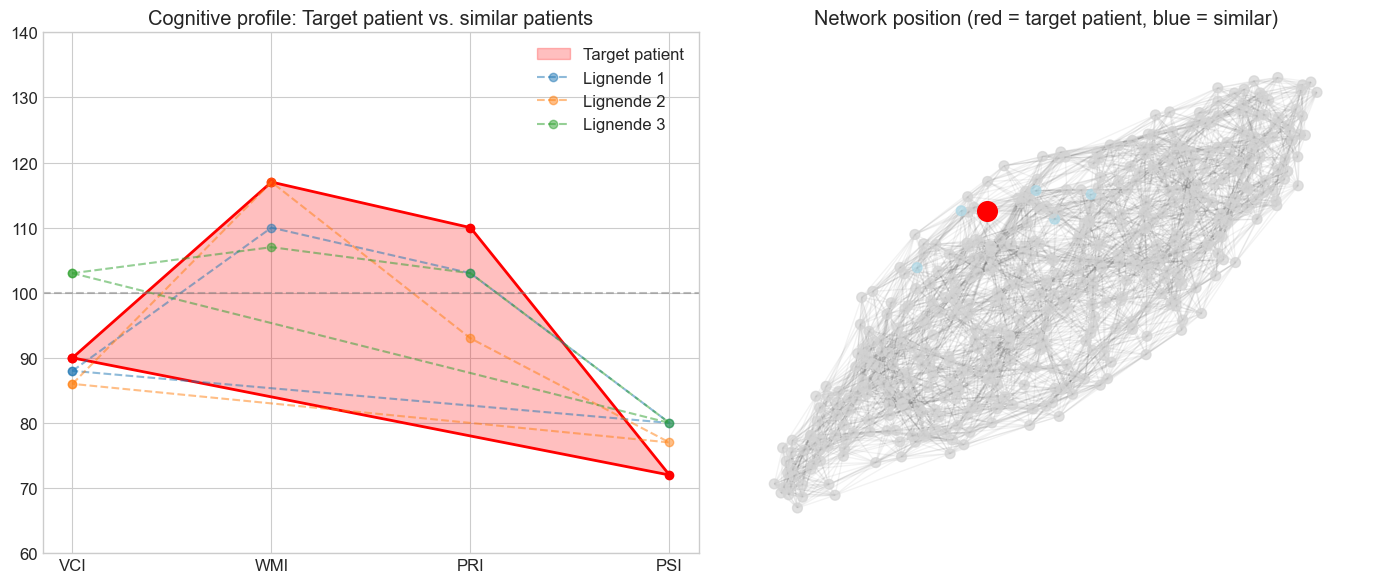


Figure 5: Case study - identification of similar patients.
  Left: Radar diagram shows cognitive profile for target patient and similar patients.
  Right: Target patient's position in PSN with the most similar neighbors marked.
  Clinical application: These similar patients can inform treatment choices.


In [13]:
# ============================================================================
# VISUALISERING AV CASE-STUDIE
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Radar-sammenligning
ax1 = axes[0]
categories = ['VCI', 'WMI', 'PRI', 'PSI']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

# Target patient
target_values = [target_patient[cat] for cat in categories]
target_values += target_values[:1]
ax1.fill(angles, target_values, alpha=0.25, color='red', label='Target patient')
ax1.plot(angles, target_values, 'o-', linewidth=2, color='red')

# Similar patients
for i, (sim_idx, _) in enumerate(similar[:3]):
    sim_patient = df.iloc[sim_idx]
    sim_values = [sim_patient[cat] for cat in categories]
    sim_values += sim_values[:1]
    ax1.plot(angles, sim_values, 'o--', alpha=0.5, label=f'Lignende {i+1}')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_ylim(60, 140)
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title('Cognitive profile: Target patient vs. similar patients')

# 2. Nettverksposisjon
ax2 = axes[1]
pos = nx.spring_layout(G_domain, seed=42)

# Color all nodes gray
node_colors = ['lightgray'] * len(G_domain.nodes())

# Mark similar patients
for sim_idx, _ in similar:
    node_colors[sim_idx] = 'lightblue'

# Target patienten
node_colors[target_idx] = 'red'

# Draw nettverk
nx.draw_networkx_edges(G_domain, pos, alpha=0.05, ax=ax2)
nx.draw_networkx_nodes(G_domain, pos, node_color=node_colors, 
                       node_size=50, alpha=0.7, ax=ax2)

# Mark target patient larger
nx.draw_networkx_nodes(G_domain, pos, nodelist=[target_idx], 
                       node_color='red', node_size=200, ax=ax2)

ax2.set_title('Network position (red = target patient, blue = similar)')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("")
print("Figure 5: Case study - identification of similar patients.")
print("  Left: Radar diagram shows cognitive profile for target patient and similar patients.")
print("  Right: Target patient's position in PSN with the most similar neighbors marked.")
print("  Clinical application: These similar patients can inform treatment choices.")


### 4.2 Subgroups with High vs. Low IQ

Let's analyze whether there are different "types" of high/low IQ based on cognitive profiles.


In [14]:
# ============================================================================
# ANALYSIS OF HIGH VS. LOW IQ GROUPS
# ============================================================================

# Del inn i IQ-grupper
df['IQ_Group'] = pd.cut(df['FSIQ'], 
                        bins=[0, 85, 115, 200], 
                        labels=['Low (<85)', 'Average (85-115)', 'High (>115)'])

print("Fordeling av IQ-grupper:")
print(df['IQ_Group'].value_counts().sort_index())

# Analyser communities innenfor hver IQ-gruppe
print("\n" + "="*60)
print("COMMUNITY-FORDELING INNENFOR HVER IQ-GRUPPE")
print("="*60)

for iq_group in ['Low (<85)', 'High (>115)']:
    group_df = df[df['IQ_Group'] == iq_group]
    print(f"\n{iq_group} IQ (n={len(group_df)}):")
    
    comm_counts = group_df['Community_Domain'].value_counts()
    for comm, count in comm_counts.items():
        comm_profile = group_df[group_df['Community_Domain'] == comm][['VCI', 'WMI', 'PRI', 'PSI']].mean()
        print(f"  Community {comm}: n={count}")
        print(f"    Profil: VCI={comm_profile['VCI']:.0f}, WMI={comm_profile['WMI']:.0f}, PRI={comm_profile['PRI']:.0f}, PSI={comm_profile['PSI']:.0f}")


Fordeling av IQ-grupper:
IQ_Group
Low (<85)            60
Average (85-115)    421
High (>115)          19
Name: count, dtype: int64

COMMUNITY-FORDELING INNENFOR HVER IQ-GRUPPE

Low (<85) IQ (n=60):
  Community 7: n=57
    Profil: VCI=79, WMI=82, PRI=81, PSI=82
  Community 4: n=3
    Profil: VCI=98, WMI=77, PRI=86, PSI=77

High (>115) IQ (n=19):
  Community 1: n=18
    Profil: VCI=120, WMI=120, PRI=116, PSI=121
  Community 5: n=1
    Profil: VCI=133, WMI=117, PRI=100, PSI=115


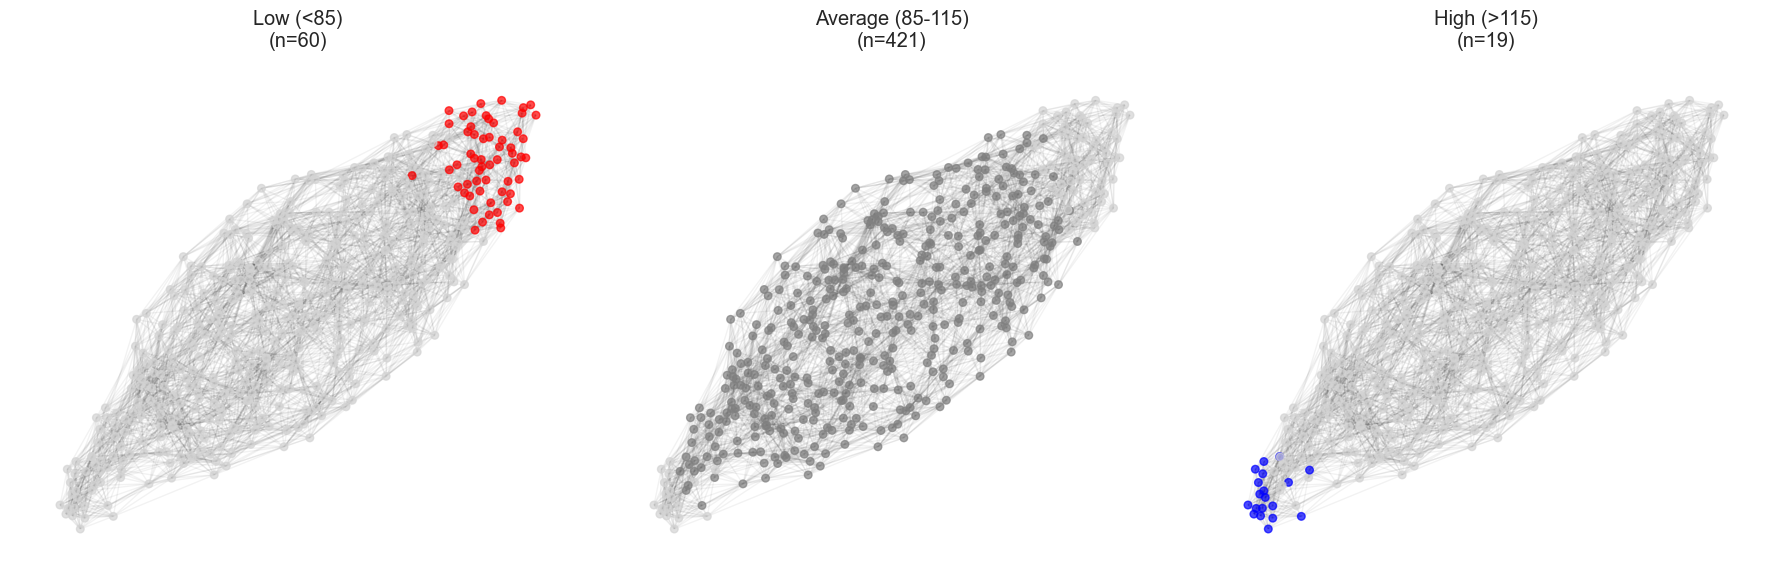


Figure 6: Distribution of IQ groups in the patient similarity network.
  Low IQ (<85): Red nodes - scattered across communities.
  Average IQ (85-115): Gray nodes - constitute the majority.
  High IQ (>115): Blue nodes - also scattered, but may have distinct profiles.

  Observation: The same IQ level can involve different cognitive profiles!
  This underscores the value of precision neuropsychology.


In [15]:
# ============================================================================
# VISUALIZATION OF IQ GROUPS IN THE NETWORK
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Layout (same for all)
pos = nx.spring_layout(G_domain, seed=42)

# Color map for IQ groups
iq_colors = {'Low (<85)': 'red', 'Average (85-115)': 'gray', 'High (>115)': 'blue'}

for i, (iq_group, color) in enumerate(iq_colors.items()):
    ax = axes[i]
    
    # Color nodes
    node_colors = [iq_colors[df.iloc[node]['IQ_Group']] 
                   if df.iloc[node]['IQ_Group'] == iq_group else 'lightgray' 
                   for node in G_domain.nodes()]
    
    # Draw
    nx.draw_networkx_edges(G_domain, pos, alpha=0.05, ax=ax)
    nx.draw_networkx_nodes(G_domain, pos, node_color=node_colors, 
                          node_size=30, alpha=0.7, ax=ax)
    
    n_group = len(df[df['IQ_Group'] == iq_group])
    ax.set_title(f'{iq_group}\n(n={n_group})')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("")
print("Figure 6: Distribution of IQ groups in the patient similarity network.")
print("  Low IQ (<85): Red nodes - scattered across communities.")
print("  Average IQ (85-115): Gray nodes - constitute the majority.")
print("  High IQ (>115): Blue nodes - also scattered, but may have distinct profiles.")
print("\n  Observation: The same IQ level can involve different cognitive profiles!")
print("  This underscores the value of precision neuropsychology.")


---

## 5. Parallels between Human Intelligence and Artificial Intelligence

Let's reflect on similarities and differences between how we measure and understand HI vs. AI.


---

## 5. Conceptual Comparison: Human Intelligence (HI) vs. Artificial Intelligence (AI)

```
╔══════════════════════════════════════════════════════════════════════════════╗
║                    HUMAN INTELLIGENCE (HI) vs. ARTIFICIAL INTELLIGENCE (AI)  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ASPECT              │  HUMAN INTELLIGENCE        │  ARTIFICIAL INTELLIGENCE ║
║ ─────────────────────┼────────────────────────────┼──────────────────────────║
║                      │                            │                          ║
║  MEASUREMENT         │  IQ tests (WAIS-IV)        │  Benchmarks (MMLU,       ║
║                      │  Standardized, normed      │  HumanEval, etc.)        ║
║                      │                            │                          ║
║  STRUCTURE           │  Hierarchical (g → domains │  Often task-specific     ║
║                      │  → subtests)               │  or emergent             ║
║                      │                            │                          ║
║  VARIATION           │  Normal distributed, cont. │ Depends on architecture, ║
║                      │ spectrum in the population │  data, and scaling       ║
║                      │                            │                          ║
║  PROFILES            │  Strengths/weaknesses      │  Generalist vs.          ║
║                      │  (VIQ ≠ PIQ possible)      │  specialist models       ║
║                      │                            │                          ║
║  DEVELOPMENT         │ Maturation → peak → decline│  Scaling, RLHF,          ║
║                      │  (Flynn effect over gen.)  │  architecture changes    ║
║                      │                            │                          ║
║  PLASTICITY          │  Training gives limited    │  Fine-tuning, prompt     ║
║                      │  improvement               │  engineering             ║
║                      │                            │                          ║
║  CONTEXT             │  Culturally dependent      │  Training data-dependent ║
║                      │                            │                          ║
║  GENERALIZATION      │  Transfer between domains  │  Out-of-distribution     ║
║                      │  (the g-factor)            │  generalization          ║
║                      │                            │                          ║
╚══════════════════════════════════════════════════════════════════════════════╝
```

### 💭 Reflections

#### 1. The g-factor and Emergent Abilities

| Human Intelligence | Artificial Intelligence |
|-------------------|---------------------|
| The positive manifold (all cognitive tests correlate) suggests an underlying *g*-factor | Large language models show "emergent" abilities that arise with scaling |

> **Question**: Is there an analog to the g-factor in AI?

#### 2. Profiles and Specialization

| Human Intelligence | Artificial Intelligence |
|-------------------|---------------------|
| Some have high VIQ but low PIQ (or vice versa) – this is clinically important | Foundation models vs. fine-tuned specialists |

> **Implication**: Both humans and AI have strengths and weaknesses.

#### 3. Measurement and Bias

| Human Intelligence | Artificial Intelligence |
|-------------------|---------------------|
| IQ tests are culturally biased, norm-dependent | Benchmarks can be contaminated, task-specific |

> **Common challenge**: How to measure "true" intelligence?

#### 4. Rehabilitation and Improvement

| Human Intelligence | Artificial Intelligence |
|-------------------|---------------------|
| Cognitive training gives limited but measurable effect | Fine-tuning, RLHF, prompt engineering |

> **Contrast**: AI is more "plastic" than human cognition.

#### 5. PSN Analog for AI?

- Could we build "model similarity networks" based on AI models' strengths?
- Which models "resemble" each other in capability profile?
- This could inform model selection for specific tasks.

#### 6. "Aging" and Norming – A Surprising Parallel

| Humans | AI Models |
|-----------|-------------|
| Raw capacity ↓ with age | Capability ↓ with "model age" |
| Age norming compensates | No standard "vintage norming" |
| 70-year-old vs. other 70-year-olds | GPT-2 vs. ??? (all models together) |
| Biological aging | Technological obsolescence |

> **Question**: Should we evaluate AI models relative to their "vintage"?
> - GPT-2 (2019) was revolutionary → "IQ = 130" in 2019 context?
> - Same model in 2025 → "IQ = 70" compared to frontier models?

**Implication**: Just as age norming reveals *relative* cognitive function, "vintage norming" of AI could reveal whether a model was innovative for its time.

<details>
<summary><b>Important Differences Between HI and AI "Aging"</b></summary>

| Aspect | Humans | AI Models |
|--------|-----------|-------------|
| **Aging** | Biological, inevitable, irreversible | Models don't "age" – they remain static while the field develops |
| **Comparison** | Same individual over time (longitudinal) | Different models from different time points (cross-sectional) |
| **Common challenge** | Absolute measures vs. relative measures | Absolute measures vs. relative measures |

</details>

---

### 5.2 Frontier Models Tested on WAIS-IV

#### 🔬 Empirical Studies: LLMs on Intelligence Tests

In October 2024, researchers published the first systematic evaluation of **multimodal large language models (MLLMs)** on WAIS-IV subtests ([Galatzer-Levy et al., 2024](https://arxiv.org/abs/2410.07391)). The study tested leading models including GPT-4o, Claude 3.5 Sonnet, and Gemini Pro.

#### 📊 Results: AI Performance on WAIS-IV Indices

| Index | AI Performance (percentile) | Humans (median) | Interpretation |
|--------|----------------------|-------------------|----------|
| **VCI** (Verbal Comprehension) | 98+ | 50 | AI far above human average |
| **WMI** (Working Memory) | 99.5+ | 50 | Exceptional – nearly "perfect" |
| **PRI** (Perceptual Reasoning) | 0.1–10 | 50 | **Dramatic failure** |
| **PSI** (Processing Speed) | Not tested | 50 | Difficult to measure on AI |

```
AI Profile vs. Average Human
                                    
     VCI    WMI    PRI    PSI      
150 ─┬──────────────────────────    
     │  ██                           AI: VCI ≈ 145
140 ─┤  ██  ██                       AI: WMI ≈ 150
     │  ██  ██                      
130 ─┤  ██  ██                      
     │  ██  ██                      
120 ─┤  ██  ██                      
     │  ██  ██                      
110 ─┤  ██  ██                      
     │  ██  ██                       Human: ~100
100 ─┼──██──██──██──██───────────   ─────────────
     │  ██  ██  ██  ██              
 90 ─┤      ▓▓  ▓▓                  
     │      ▓▓  ▓▓                  
 80 ─┤      ▓▓  ▓▓                  
     │          ▓▓                  
 70 ─┤          ▓▓                   AI: PRI ≈ 60-75
     │          ▓▓                  
 60 ─┴──────────▓▓──────────────    

     ██ = AI    ▓▓ = AI (weak)    ── = Human average
```

#### ⚠️ Challenges with AI on WAIS-IV

<details>
<summary>🔍 <b>Click for detailed analysis of the challenges</b></summary>

##### 1. Visual Reasoning (PRI)

**Why does AI fail at visual reasoning?**

| Subtest | Challenge for AI | Example |
|---------|-------------------|----------|
| Block Design | Requires spatial manipulation | Mentally rotate 3D objects |
| Matrix Reasoning | Abstract visual patterns | "What is missing in the sequence?" |
| Visual Puzzles | Spatial deconstruction | "Which pieces form this?" |

> *"Despite being 'multimodal', current vision-language models perform between the 0.1st and 10th percentile on perceptual reasoning tasks"* — Galatzer-Levy et al. (2024)

**Possible causes:**
- Training primarily on text, not visual manipulation
- Lacks embodied/sensorimotor experience
- 2D images don't provide enough information for 3D reasoning
- Statistical pattern recognition ≠ spatial understanding

##### 2. Working Memory (WMI) – Why So Good?

| Subtest | Why AI masters this |
|---------|--------------------------|
| Digit Span | Perfect number memory (no capacity limit) |
| Arithmetic | Mathematics is a core strength |
| Letter-Number Seq. | Simple sequence manipulation |

**However**: AI doesn't have *real* working memory in a cognitive sense – it simulates it via context window.

##### 3. Verbal Comprehension (VCI) – Natural Strength

| Subtest | AI Advantage |
|---------|-----------|
| Vocabulary | Trained on billions of words |
| Similarities | Semantic relations are core training |
| Information | Encyclopedic knowledge |
| Comprehension | Pragmatic understanding (but culture-specific) |

##### 4. Processing Speed (PSI) – Impossible to Compare?

PSI measures:
- Speed in visual scanning
- Tempo in hand-eye coordination
- Mental efficiency under time pressure

**Problem**: AI doesn't have "reaction time" in a human sense. API latency ≠ cognitive speed.

</details>

#### 🔄 Update: VisFactor Benchmark (2025)

A more recent study ([VisFactor, 2025](https://arxiv.org/abs/2502.16435)) tested fundamental visual cognitive abilities:

| Task | GPT-4o | Gemini Pro | Humans |
|---------|--------|------------|-----------|
| Spatial rotation | ~random | ~random | 85%+ |
| Visual search | 40% | 35% | 90%+ |
| Mental folding | 25% | 20% | 75%+ |

> *"Even with advanced prompting techniques, performance was often near random guessing"*

---

### 5.3 Clinical Implications: Can AI Be Used in Neuropsychological Assessment?

| Application | Suitability | Justification |
|------------|----------|-------------|
| **Screening (verbal)** | ✅ Good | High VCI performance, consistent |
| **Full assessment** | ⚠️ Limited | Lacks visual/perceptual component |
| **Adaptive testing** | ✅ Promising | Can adjust difficulty level |
| **Scoring/interpretation** | ✅ Good | Objective, consistent |
| **Rehabilitation planning** | ⚠️ Supplementary | Lacks embodied understanding* |

> **\*Embodied understanding** (*embodied cognition*): The theory that cognition is fundamentally shaped by the body and its physical interactions with the world. Humans learn spatial reasoning by *moving*, *touching*, and *manipulating* objects – not just by seeing images. AI has never "held a block" or "felt gravity", and therefore lacks the intuitive understanding that comes from bodily experience. This limits AI's ability to advise on physical rehabilitation, motor training, or everyday practical challenges.

<details>
<summary>🧠 <b>Deep Dive: Embodied Cognition – Why the Body Matters for Thought</b></summary>

### What is Embodied Cognition?

**Embodied cognition** is a theory in cognitive science that claims:

> *"The mind is not just located in the brain, but extends into the body and environment"* — Clark & Chalmers (1998)

This contrasts with traditional cognitive science that viewed the brain as a "computer" processing abstract symbols independently of the body.

---

### Humans vs. AI: Fundamental Difference

| Aspect | Humans | AI (LLMs) |
|--------|-----------|-----------|
| **Existence** | Physical body in the world | Software on servers |
| **Experience with gravity** | Has *felt* things fall | Has *read* that things fall |
| **Spatial intuition** | Built up through movement | Statistical patterns from images |
| **Learning** | Sensorimotor + visual + verbal | Only text and static images |

---

### Concrete Example: Block Design (WAIS-IV)

```
Task: Mentally rotate these blocks to match the pattern

    ┌───┐      ┌───────────┐
    │ ╲ │  →   │   ?   ?   │
    └───┘      └───────────┘
```

**Human**: 
- Has stacked Lego as a child
- Has *felt* how blocks rotate in the hands
- Can activate motor areas in the brain for mental rotation
- Solves the task in 5-10 seconds

**AI (GPT-4o)**:
- Has seen millions of images of blocks
- Has never *held* or *rotated* a block
- Tries to solve it via statistical pattern recognition
- Performs at 0.1-10th percentile (dramatic failure)

---

### Scientific Evidence

#### 1. Motor Experience Activates Visual Areas

Studies with fMRI show that when experienced pianists *see* a piano, motor areas in the brain are activated – even when they are not playing. The brain has linked the sight of the instrument to the experience of using it.

#### 2. Blind from Birth and Spatial Reasoning

People who are blind from birth can still develop good spatial reasoning – through *touch* and *movement*. This shows that spatial understanding does not primarily come from vision, but from bodily interaction.

#### 3. Children's Learning

Children don't learn spatial reasoning by *looking at* blocks – they learn by *playing with* them. Developmental psychology shows that sensorimotor play is fundamental for cognitive development (Piaget).

---

### Implications for AI

| Cognitive Ability | Requires Embodiment? | AI Performance |
|---------------|-------------------|-----------|
| Vocabulary | No | ✅ Exceptional |
| Arithmetic | No | ✅ Exceptional |
| Semantic relations | Partially | ✅ Good |
| Mental rotation | **Yes** | ❌ Weak |
| Spatial navigation | **Yes** | ❌ Weak |
| Physical intuition | **Yes** | ❌ Weak |

---

### Clinical Relevance for Rehabilitation

When a neuropsychologist plans rehabilitation for a patient with spatial difficulties:

| Task | Requires Embodied Understanding? | AI as Aid? |
|---------|----------------------------|---------------------|
| Interpret test results | No | ✅ Useful |
| Understand patient's frustrations | Yes | ⚠️ Limited |
| Suggest physical exercises | **Yes** | ❌ Unreliable |
| Assess assistive devices (walker, etc.) | **Yes** | ❌ Lacks experience |
| Write report | No | ✅ Useful |

---

### The Future: Embodied AI?

Robotics research is working to give AI bodily experience:

- **Robots with tactile sensors** – can "feel" objects
- **Simulated physics environments** – virtual embodiment
- **Reinforcement learning in 3D worlds** – learns through action

But as of 2025, no text-based LLM (GPT-4, Claude, etc.) has this type of experience.

---

### Key References

- Clark, A. & Chalmers, D. (1998). The extended mind. *Analysis*, 58(1), 7-19. [DOI](https://doi.org/10.1093/analys/58.1.7)
- Barsalou, L.W. (2008). Grounded cognition. *Annual Review of Psychology*, 59, 617-645. [DOI](https://doi.org/10.1146/annurev.psych.59.103006.093639)
- Wilson, M. (2002). Six views of embodied cognition. *Psychonomic Bulletin & Review*, 9(4), 625-636. [DOI](https://doi.org/10.3758/BF03196322)
- Piaget, J. (1952). *The Origins of Intelligence in Children*. International Universities Press.

</details>

#### 💡 Implications for PSN

If we were to create PSN for AI models (thought experiment):
- **Communities would look completely different** than for humans
- AI models would cluster based on architecture, not "personality"
- No continuous distribution – more discrete categories

---

### 📚 References

- Galatzer-Levy, I.R. et al. (2024). *The Cognitive Capabilities of Generative AI: A Comparative Analysis with Human Benchmarks*. arXiv:2410.07391. [Link](https://arxiv.org/abs/2410.07391)
- VisFactor Team (2025). *VisFactor: Evaluating Visual Cognitive Abilities in MLLMs*. arXiv:2502.16435. [Link](https://arxiv.org/abs/2502.16435)

---


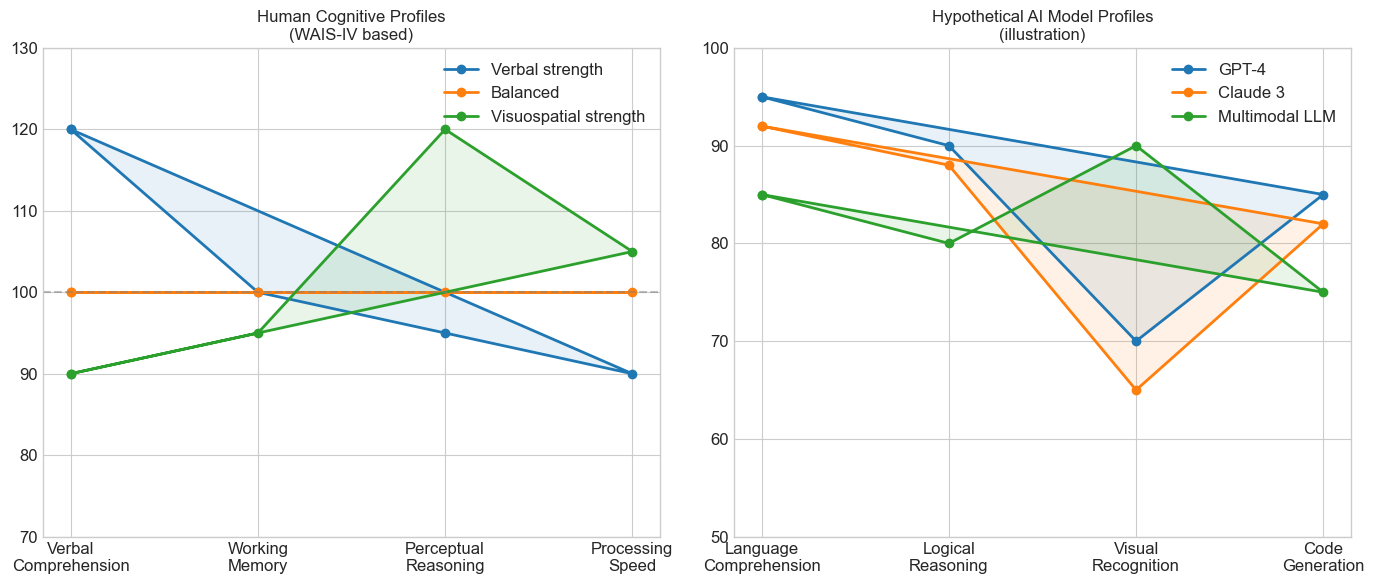


Figure 7: Parallels between human and AI-based 'cognitive' profiles.
  Left: Actual human profiles based on WAIS-IV indices.
  Right: Hypothetical AI profiles (illustration - not real data).
  Main point: Both humans and AI have strengths and weaknesses.
  The PSN approach could theoretically be used for both!


In [16]:
# ============================================================================
# VISUALIZATION: HI PROFILES AS INSPIRATION FOR AI THINKING
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Human cognitive profiles (from our data)
ax1 = axes[0]
categories = ['Verbal\nComprehension', 'Working\nMemory', 'Perceptual\nReasoning', 'Processing\nSpeed']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

# Three example profiles
profiles = [
    ('Verbal strength', [120, 100, 95, 90]),
    ('Balanced', [100, 100, 100, 100]),
    ('Visuospatial strength', [90, 95, 120, 105])
]

for name, values in profiles:
    values_plot = values + [values[0]]
    ax1.plot(angles, values_plot, 'o-', linewidth=2, label=name)
    ax1.fill(angles, values_plot, alpha=0.1)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_ylim(70, 130)
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title('Human Cognitive Profiles\n(WAIS-IV based)', fontsize=12)

# 2. Hypothetical AI profiles
ax2 = axes[1]
ai_categories = ['Language\nComprehension', 'Logical\nReasoning', 'Visual\nRecognition', 'Code\nGeneration']

ai_profiles = [
    ('GPT-4', [95, 90, 70, 85]),
    ('Claude 3', [92, 88, 65, 82]),
    ('Multimodal LLM', [85, 80, 90, 75])
]

for name, values in ai_profiles:
    values_plot = values + [values[0]]
    ax2.plot(angles, values_plot, 'o-', linewidth=2, label=name)
    ax2.fill(angles, values_plot, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(ai_categories)
ax2.set_ylim(50, 100)
ax2.legend(loc='upper right')
ax2.set_title('Hypothetical AI Model Profiles\n(illustration)', fontsize=12)

plt.tight_layout()
plt.show()

print("")
print("Figure 7: Parallels between human and AI-based 'cognitive' profiles.")
print("  Left: Actual human profiles based on WAIS-IV indices.")
print("  Right: Hypothetical AI profiles (illustration - not real data).")
print("  Main point: Both humans and AI have strengths and weaknesses.")
print("  The PSN approach could theoretically be used for both!")


<details>
<summary>📊 <b>Deep Dive: AI Benchmarks for the Four Domains</b></summary>

### How Do We Measure AI "Intelligence"?

The figure above uses four domains that correspond to key cognitive abilities. Here we explain which benchmarks are used for each domain:

---

#### 1. 🗣️ Language Comprehension (Verbal Comprehension)

| Benchmark | What It Measures | Typical Task |
|-----------|---------------|----------------|
| **MMLU** | Academic knowledge (57 subjects) | Multiple choice from law, medicine, history, etc. |
| **HellaSwag** | Commonsense reasoning | "What probably happens next?" |
| **ARC** | Scientific understanding | Science questions from elementary to high school |
| **TruthfulQA** | Factual accuracy | Avoid common misconceptions |

**Typical Scores (2025):**
| Model | MMLU | HellaSwag |
|--------|------|-----------|
| GPT-3.5 | ~70% | ~85% |
| GPT-4o | ~88% | ~95% |
| Claude 3.5 Sonnet | ~89% | ~95% |
| Claude Opus 4 | ~92% | ~97% |

---

#### 2. 🧮 Logical Reasoning (Fluid Reasoning)

| Benchmark | What It Measures | Typical Task |
|-----------|---------------|----------------|
| **GPQA** | Expert-level science | PhD-level physics, chemistry, biology |
| **MATH** | Mathematical problem solving | Olympiad mathematics |
| **GSM8K** | Arithmetic reasoning | Multi-step word problems |
| **ARC-AGI** | Abstract reasoning | Visual pattern recognition (difficult!) |

**Typical Scores (2025):**
| Model | GPQA | MATH | GSM8K |
|--------|------|------|-------|
| GPT-3.5 | ~28% | ~35% | ~58% |
| GPT-4o | ~53% | ~76% | ~95% |
| Claude 3.5 Sonnet | ~55% | ~78% | ~96% |
| Claude Opus 4 | ~60% | ~82% | ~97% |

> ⚠️ **ARC-AGI** remains difficult: Even frontier models score <50%

---

#### 3. 👁️ Visual Recognition (Perceptual Reasoning)

| Benchmark | What It Measures | Typical Task |
|-----------|---------------|----------------|
| **MMMU** | Multimodal understanding | Questions about diagrams, figures, art |
| **MathVista** | Visual mathematics | Geometry, graphs, tables |
| **ChartQA** | Chart comprehension | Reading and interpreting diagrams |
| **AI2D** | Scientific diagrams | Understanding biological/physical diagrams |

**Typical Scores (2025):**
| Model | MMMU | MathVista |
|--------|------|-----------|
| GPT-3.5 | ~35% | ~38% |
| GPT-4o | ~69% | ~63% |
| Claude 3.5 Sonnet | ~65% | ~61% |
| Claude Opus 4 | ~74% | ~68% |

> 📈 **Fastest improvement**: Visual reasoning has seen the greatest progress 2023→2025

---

#### 4. 💻 Code Generation (Processing/Execution)

| Benchmark | What It Measures | Typical Task |
|-----------|---------------|----------------|
| **HumanEval** | Python programming | Implement function from docstring |
| **SWE-bench** | Realistic software development | Fix GitHub issues in real repos |
| **MBPP** | Basic programming | Simpler Python tasks |
| **LiveCodeBench** | Fresh code (no leakage) | New tasks after training data |

**Typical Scores (2025):**
| Model | HumanEval | SWE-bench |
|--------|-----------|-----------|
| GPT-3.5 | ~48% | ~2% |
| GPT-4o | ~90% | ~38% |
| Claude 3.5 Sonnet | ~92% | ~49% |
| Claude Opus 4 | ~95% | ~55% |

> 🏆 **Claude models lead** on code benchmarks (as of 2025)

---

### 🔄 Mapping: WAIS-IV → AI Benchmarks

| WAIS-IV Domain | AI Benchmarks | Similarity | Difference |
|----------------|---------------|--------|-----------|
| **VCI** (Verbal) | MMLU, HellaSwag | Both measure language comprehension | AI: broader knowledge, HI: deeper understanding |
| **WMI** (Working Memory) | (Context window) | Both hold info "in memory" | AI: much larger capacity, but passive |
| **PRI** (Perceptual) | MMMU, MathVista | Both require visual analysis | AI: weaker on 3D spatial understanding |
| **PSI** (Processing Speed) | HumanEval, SWE-bench | Both measure fast execution | AI: millions× faster, but different process |

---

### 📚 References for Benchmark Data

- **MMLU**: Hendrycks et al. (2021). [Measuring Massive Multitask Language Understanding](https://arxiv.org/abs/2009.03300)
- **GPQA**: Rein et al. (2023). [GPQA: A Graduate-Level Google-Proof Q&A Benchmark](https://arxiv.org/abs/2311.12022)
- **MMMU**: Yue et al. (2024). [MMMU: A Massive Multi-discipline Multimodal Understanding Benchmark](https://arxiv.org/abs/2311.16502)
- **SWE-bench**: Jimenez et al. (2024). [SWE-bench: Can Language Models Resolve Real-World GitHub Issues?](https://arxiv.org/abs/2310.06770)
- **Leaderboards**: [lmsys.org/leaderboard](https://chat.lmsys.org/?leaderboard), [paperswithcode.com](https://paperswithcode.com/sota)

</details>


---

## 6. Discussion and Clinical Implications

### 6.1 What Have We Learned?

1. **Granularity matters**: PSN at item level reveals finer nuances than domain level.

2. **Same IQ ≠ same profile**: Two patients with FSIQ=95 can have completely different strengths/weaknesses.

3. **Communities represent profiles**: The subgroups in PSN reflect cognitive profiles, not just IQ level.

4. **Precision neuropsychology is possible**: PSN can identify similar patients for personalized treatment.

### 6.2 Clinical Applications

| Application | Description | PSN Contribution |
|------------|-------------|------------|
| **Rehabilitation** | Cognitive training | Find patients who responded to similar interventions |
| **Career guidance** | Career choice | Match cognitive profile with job requirements |
| **Educational support** | Accommodations | Identify specific learning needs |
| **Diagnostics** | Differential diagnosis | Distinguish between global vs. specific difficulties |
| **Prognosis** | Expected development | See what happened with similar patients |

### 6.3 Limitations

- **Simulated data**: Real WAIS-IV data would give more realistic results
- **Simplification**: We don't include all WAIS-IV aspects
- **Static analysis**: Cognition changes over time
- **Missing context**: Other factors (motivation, health) affect test performance


---

## 7. Exercises and Reflection Questions

### 📝 Exercises

1. **Change parameters**: Try different values for `k_nearest` in the PSN construction. How does this affect the number of communities?

2. **Analyze age effects**: Build separate PSNs for young (<40) and older (>60). Is the community structure different?

3. **Explore the item level**: Which subtests contribute most to distinguishing between communities?

4. **Qualitative descriptors**: Use the NNF table for qualitative descriptors (see section 1) to classify patients in each community. How are the groups distributed from "Very Low" to "Very High"?

5. **Similarity measures and variable types** ⭐ (Challenging):
   
   a) **Continuous variables**: Compare PSN built with Euclidean distance vs. Cosine similarity. Do you get different communities? What is the clinical difference?
   
   b) **Categorical variables**: The dataset contains `Gender` (M/F). How can you include gender in the similarity calculation? Try using *Gower distance* or *one-hot encoding*.
   
   c) **Ordinal variables**: `Education` is ordinal (1-5). Should it be treated as continuous, categorical, or something in between? Experiment with different approaches.
   
   d) **Mixed data**: Build a PSN that combines cognitive scores (continuous) with gender (categorical) and education (ordinal). How do you weight the different variables?
   
   *Hint: See section 3.1 on similarity measures and the table below for guidance.*

<details>
<summary>📊 <b>Guidance: Similarity Measures for Different Variable Types</b></summary>

| Variable Type | Examples | Distance Measure | Python Implementation |
|--------------|-----------|-------------|----------------------|
| **Continuous** | VCI, WMI, FSIQ, Age | Euclidean, Manhattan, Cosine | `scipy.spatial.distance.pdist()` |
| **Categorical (nominal)** | Gender, Diagnosis | Hamming, Jaccard | `scipy.spatial.distance.hamming()` |
| **Ordinal** | Education, Severity | Spearman correlation, or treat as continuous | Rank the values first |
| **Mixed** | All of the above | Gower distance | `gower` package, or manual combination |

#### Gower Distance

For mixed data, **Gower distance** (1971) is a classic solution:

$$d_{ij} = \frac{\sum_k w_k \cdot d_{ij}^{(k)}}{\sum_k w_k}$$

where:
- $d_{ij}^{(k)}$ is the distance for variable $k$ (scaled to [0,1])
- $w_k$ is the weight for variable $k$
- For categorical: $d_{ij}^{(k)} = 0$ if same, $1$ if different
- For continuous: $d_{ij}^{(k)} = |x_i - x_j| / \text{range}$

#### One-Hot Encoding for Categorical Variables

```python
# Example: Gender as two binary columns
Gender_M: [1, 0, 1, 0, ...]  # 1 if male
Gender_F: [0, 1, 0, 1, ...]  # 1 if female
```

Then Euclidean distance can be used on the expanded feature matrix.

</details>

### 💭 Reflection Questions

1. **Clinical validity**: How would you validate that PSN-based groupings are clinically meaningful? 
   - *Hint: See the NNF guideline discussion on ecological validity (p. 16)*

2. **Ethical considerations**: What ethical challenges do you see with using PSN for precision neuropsychology?
   - *Hint: See the NNF guideline's professional ethics chapter (p. 6) and discussion of privacy*

3. **HI vs. AI**: Do you think AI will ever have a "g-factor"? Why/why not?
   - *Hint: See the NNF guideline's section on AI in neuropsychological practice (p. 36)*

4. **The future**: How can PSN be combined with other data sources (imaging, genetics) for even better patient matching?

5. **Reporting**: How would you present PSN results in a neuropsychological report?
   - *Hint: See the NNF guideline's guidelines for report writing (p. 16-21)*

<details>
<summary>📋 <b>NNF Guideline Recommendations for Results Presentation</b></summary>

According to NNF (2024, pp. 18-20):

> *"Results should be presented in a way that allows the recipient to evaluate the test person's performance relative to expectations [...] It is recommended to use qualitative descriptors as a supplement to quantitative scores."*

**Recommended practice:**
- Use standardized scores (z-scores, T-scores, index scores)
- Provide confidence intervals where relevant
- Use graphical representations to illustrate profiles
- Compare with relevant norm groups (age, education)

</details>


---

## 8. Summary

In this notebook we have:

✅ Simulated realistic WAIS-IV data for 500 individuals

✅ Built patient similarity networks at three levels of granularity

✅ Identified cognitive subgroups through community detection

✅ Demonstrated precision neuropsychology: Finding similar patients

✅ Reflected on parallels between human and artificial intelligence

✅ Applied NNF guidelines for qualitative descriptors and interpretation

**Main message**: Patient similarity networks are a powerful tool for uncovering cognitive profiles and enabling personalized neuropsychological assessment and intervention.

> 📋 **Clinical grounding**: This notebook is informed by the *Guide to Clinical Neuropsychology* (NNF, 2024), which describes principles for responsible practice of clinical neuropsychological activities in Norway.

---

## 📚 Further Reading

### Primary Sources
- **Norwegian Neuropsychological Association (2024)**. *Guide to Clinical Neuropsychology – principles for clinical neuropsychological practice*. [nevropsyk.org](https://nevropsyk.org)
- Wechsler, D. (2008). *WAIS-IV Technical and Interpretive Manual*. Pearson.
- Carroll, J. B. (1993). *Human Cognitive Abilities*. Cambridge University Press.

### Networks and Precision Neuropsychology
- Barabási, A.-L. et al. (2011). Network medicine: a network-based approach to human disease. *Nature Reviews Genetics*.
- Addressing challenges in precision neuropsychology: A focus on patient similarity networks. *Clinical Neuropsychologist*.

### Artificial Intelligence in Neuropsychology
- See the NNF guide's section on *Artificial Intelligence in Neuropsychological Practice* (p. 36)

---

*Notebook developed for BMED365 - Computational Imaging, Modeling and AI in Biomedicine, 2026*
